# Dyslexia Load Index (DLI) - Analysis Notebook

Full analysis pipeline for the Arabic Dyslexia Load Index (DLI) thesis.

**Sections:**
1. Setup & Imports
2. Data Loading & Preprocessing
3. Corpus Analysis
4. LLM Proxy Evaluation
5. Feature Importance Analysis
6. Weighted DLI
7. Additional Factors Analysis
8. SVR Model
9. Figures

> **Note:** Run sections in order. API cells cost credits - load from saved CSVs where indicated.

## 1. Setup & Imports

In [73]:
# ==============================================================================
# Setup & Imports
# ==============================================================================
import re
import os
import sys
import json
import asyncio
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from collections import Counter
from dotenv import load_dotenv

# Add src to path
sys.path.append(os.path.join(os.getcwd(), '..'))

# Load environment variables
load_dotenv(override=True)

# Import DLI modules
# NOTE: src/main.py takes ~30 seconds to load on first import (CAMeL Tools)
import src.llm_experiments as llm_experiments
importlib.reload(llm_experiments)
from src.llm_experiments import *

import src.main as main_module
importlib.reload(main_module)
from src.main import *

from src.svr_model import FEATURE_COLS, train_svr, predict_svr, save_model, load_model

print("All imports successful!")


All imports successful!


In [74]:
samer_lookup = pd.read_csv('../data/lookups/samer_lookup.csv')
samer_lookup_pos = pd.read_csv('../data/lookups/samer_lookup_lemma.csv')
samer_surface_homographs = set(pd.read_csv('../data/lookups/samer_surface_homographs.csv')['Plain_Form'].tolist())

## 2. Data Loading & Preprocessing

In [85]:
# Load pre-computed DLI annotations (fast path — recommended)
# To recompute from scratch instead, comment this cell and run Cells 6-7 above (~30 min)
df_full = pd.read_csv('../results/annotated/barec_dli_full_Final.csv')

# Compute normalized DLI variants (fast, no CAMeL Tools needed)
df_full['DLI_1_5'] = df_full['DLI'].apply(lambda x: round(1 + (x / 22) * 4, 2))
observed_max = df_full['DLI'].max()
df_full['DLI_1_5_norm'] = df_full['DLI'].apply(lambda x: round(1 + (x / observed_max) * 4, 2))

print(f"Loaded: {len(df_full)} sentences")
print(df_full[['DLI', 'DLI_1_5_norm', 'Readability_Level_19']].describe().round(3))


Loaded: 69441 sentences
             DLI  DLI_1_5_norm  Readability_Level_19
count  69441.000     69441.000             69441.000
mean       6.179         2.545                10.555
std        1.777         0.444                 3.258
min        0.000         1.000                 1.000
25%        5.000         2.250                 8.000
50%        6.000         2.500                11.000
75%        7.000         2.750                13.000
max       16.000         5.000                19.000


In [76]:
# FROM-SCRATCH RECOMPUTATION — skip Cells 6-8 if loading from saved CSV below
# Only run these if you want to recompute DLI features from raw BAREC data (~30 min)
train = pd.read_parquet('../data/barec/trainData.parquet')
dev = pd.read_parquet('../data/barec/devData.parquet')
test = pd.read_parquet('../data/barec/testData.parquet')

print(train.shape, dev.shape, test.shape)
print(train.columns.tolist())

(54845, 19) (7310, 19) (7286, 19)
['ID', 'Sentence', 'Word_Count', 'Word', 'Lex', 'D3Tok', 'D3Lex', 'Readability_Level', 'Readability_Level_19', 'Readability_Level_7', 'Readability_Level_5', 'Readability_Level_3', 'Annotator', 'Document', 'Source', 'Book', 'Author', 'Domain', 'Text_Class']


In [77]:
# FROM-SCRATCH RECOMPUTATION (continued)
barec = pd.concat([train, dev, test], ignore_index=True)
print(f"Total rows: {len(barec)}")

barecSampledf = barec[['ID', 'Sentence', 'Word_Count', 'Readability_Level',
                        'Readability_Level_19', 'Readability_Level_7',
                        'Readability_Level_5', 'Readability_Level_3',
                        'Domain', 'Source', 'Text_Class']].copy()

print(f"Total sentences: {len(barecSampledf)}")
print(f"\nReadability_Level_19 distribution:")
print(barecSampledf['Readability_Level_19'].value_counts().sort_index())
print(f"\nDomain distribution:")
print(barecSampledf['Domain'].value_counts())

Total rows: 69441
Total sentences: 69441

Readability_Level_19 distribution:
Readability_Level_19
1       409
2       437
3      1462
4       751
5      3443
6      1534
7      5438
8      5683
9      2023
10     9763
11     4914
12    14471
13     4039
14    10687
15     2547
16     1141
17      480
18      103
19      116
Name: count, dtype: int64

Domain distribution:
Domain
Arts & Humanities    50442
Social Sciences      14319
STEM                  4680
Name: count, dtype: int64


## 3. Corpus Analysis

In [78]:
def show_quadrant(quadrant_name, n=5):
    subset = df_full[df_full['Quadrant'] == quadrant_name].copy()
    if 'High DLI' in quadrant_name:
        subset = subset.nlargest(n, 'DLI')
    else:
        subset = subset.nsmallest(n, 'DLI')
    
    for _, row in subset.iterrows():
        print(f"Sentence:     {row['Sentence'][:80]}")
        print(f"BAREC: {row['Readability_Level_19']}  |  DLI: {row['DLI']}  |  Domain: {row['Domain']}  |  Class: {row['Text_Class']}")
        print(f"OVL:      {row['OVL']:.2f}  |  DLP:          {row['DLP']:.2f}  |  Dot_Load: {row['Dot_Load_Ratio']:.2f}")
        print(f"Shape:    {row['Similar_Shape_Density']:.2f}  |  PSC:          {row['PSC_Density']:.2f}")
        print(f"Lex:      {row['Lexical_Difficulty']:.2f}  |  Homograph:    {row['Homograph_Risk']:.2f}  |  Morph: {row['Avg_Morphological_Complexity']:.2f}")
        print()

print("=" * 70)
print("LOW BAREC / HIGH DLI — easy to comprehend, hard to decode")
print("=" * 70)
show_quadrant('Low BAREC / High DLI')

print("=" * 70)
print("HIGH BAREC / LOW DLI — hard to comprehend, easy to decode")
print("=" * 70)
show_quadrant('High BAREC / Low DLI')

LOW BAREC / HIGH DLI — easy to comprehend, hard to decode
Sentence:     يُعْجِبُني
BAREC: 5  |  DLI: 16  |  Domain: Arts & Humanities  |  Class: Foundational
OVL:      0.67  |  DLP:          0.83  |  Dot_Load: 1.17
Shape:    1.00  |  PSC:          0.33
Lex:      3.00  |  Homograph:    0.00  |  Morph: 1.00

Sentence:     بِسْبِسَةُ زَعْلانَةٌ، تَعْبانَةٌ، عَيَّانَةٌ.
BAREC: 9  |  DLI: 14  |  Domain: Arts & Humanities  |  Class: Foundational
OVL:      0.82  |  DLP:          0.59  |  Dot_Load: 0.86
Shape:    0.64  |  PSC:          0.14
Lex:      3.50  |  Homograph:    0.00  |  Morph: 1.25

Sentence:     بِسْبِسَةُ صَرَخَتْ تُصَحِّي دِعْبِسَةَ وَنَرْجِسَةَ.
BAREC: 6  |  DLI: 14  |  Domain: Arts & Humanities  |  Class: Foundational
OVL:      1.00  |  DLP:          0.50  |  Dot_Load: 0.75
Shape:    0.83  |  PSC:          0.17
Lex:      2.90  |  Homograph:    0.00  |  Morph: 0.80

Sentence:     هَدَيْتَني وَرَزَقْتَني
BAREC: 9  |  DLI: 14  |  Domain: Arts & Humanities  |  Class: Foundational


In [79]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from scipy import stats

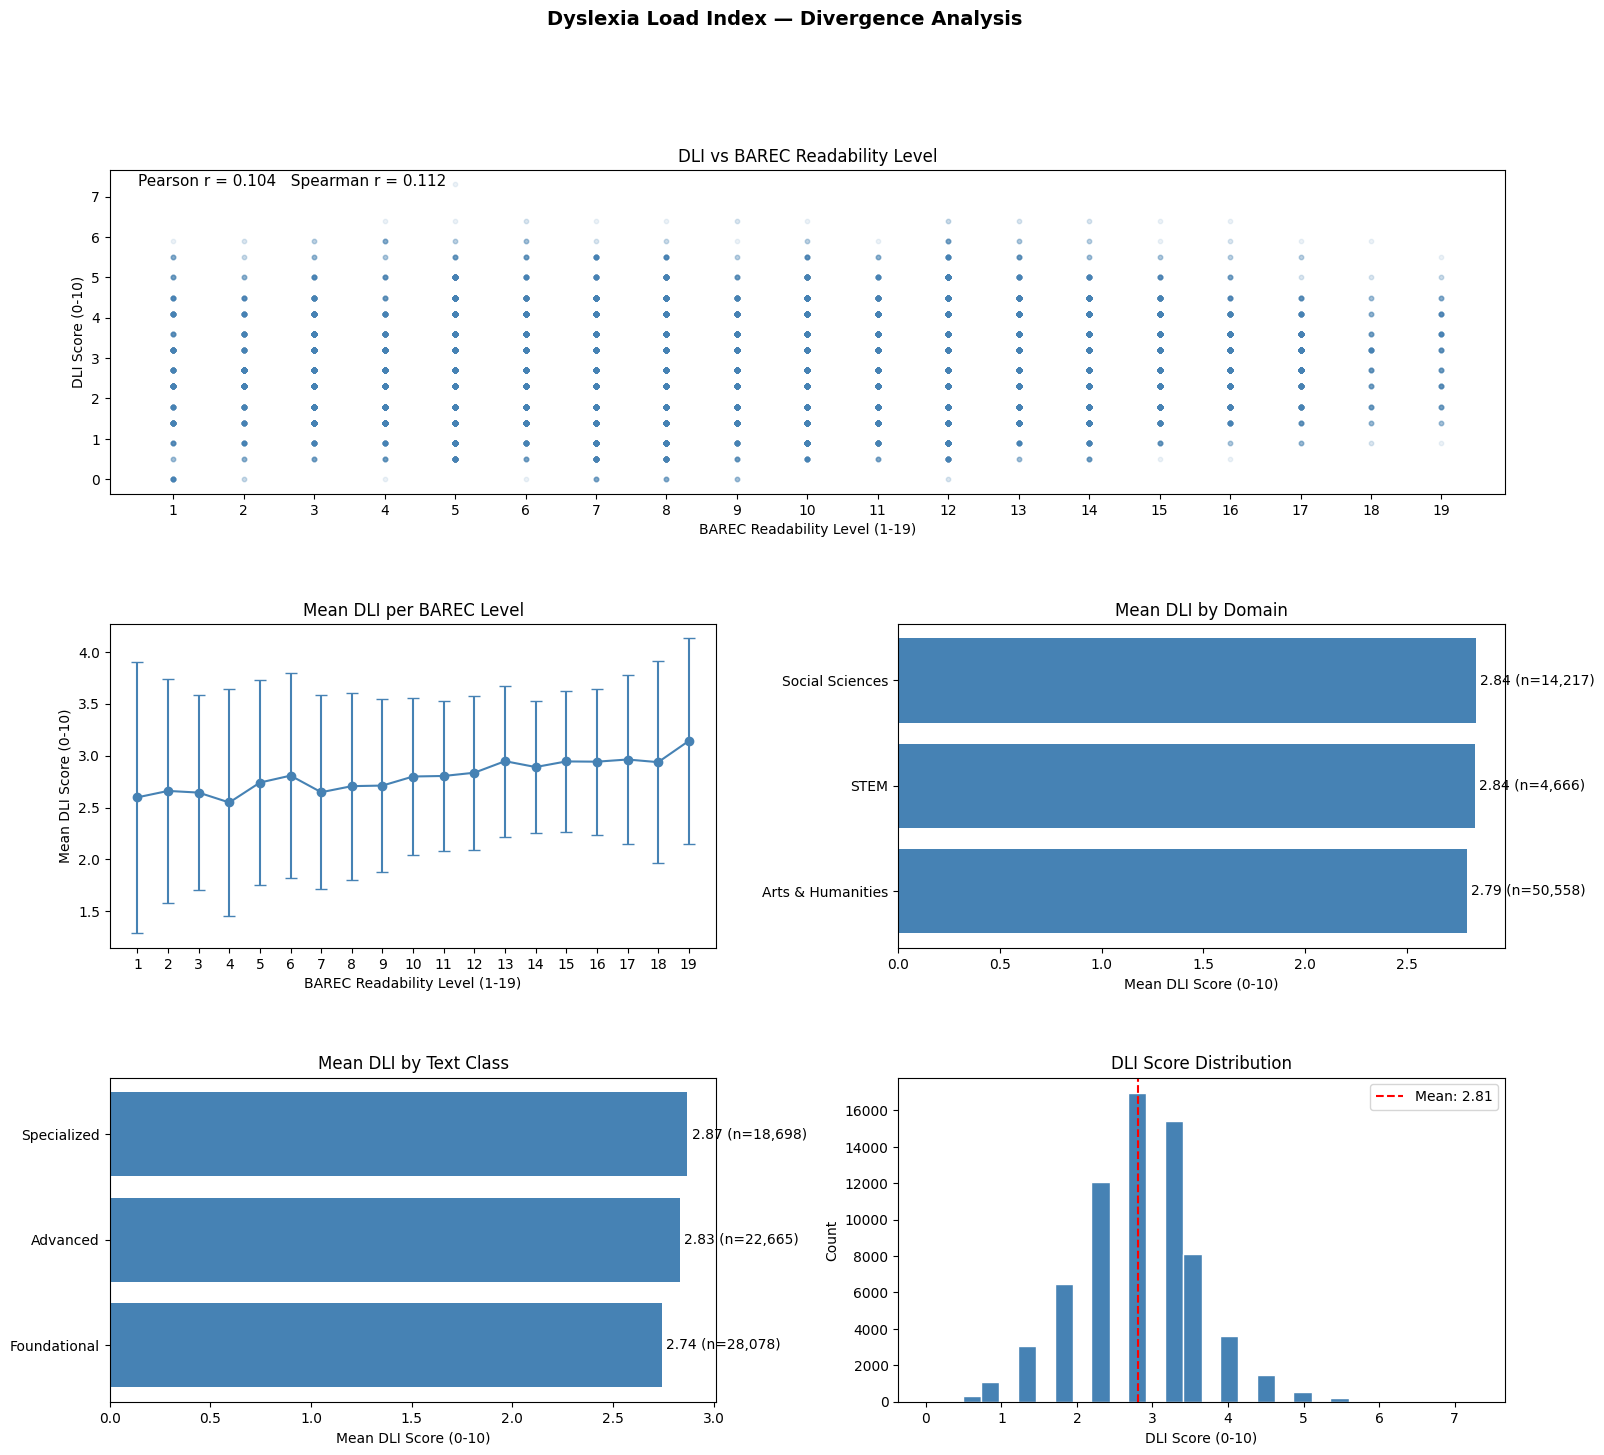

Saved!


In [ ]:
fig = plt.figure(figsize=(18, 16))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.3)

# 1. Scatter — DLI_10 vs BAREC level
ax1 = fig.add_subplot(gs[0, :])
ax1.scatter(df_full['Readability_Level_19'], df_full['DLI_10'], 
            alpha=0.1, s=10, color='steelblue')
ax1.set_xlabel('BAREC Readability Level (1-19)')
ax1.set_ylabel('DLI Score (0-10)')
ax1.set_title('DLI vs BAREC Readability Level')
ax1.set_xticks(range(1, 20))
pearson_r, _ = stats.pearsonr(df_full['Readability_Level_19'], df_full['DLI_10'])
spearman_r, _ = stats.spearmanr(df_full['Readability_Level_19'], df_full['DLI_10'])
ax1.text(0.02, 0.95, f'Pearson r = {pearson_r:.3f}   Spearman r = {spearman_r:.3f}', 
         transform=ax1.transAxes, fontsize=11)

# 2. Mean DLI per BAREC level
ax2 = fig.add_subplot(gs[1, 0])
level_means = df_full.groupby('Readability_Level_19')['DLI_10'].agg(['mean', 'std'])
ax2.errorbar(level_means.index, level_means['mean'], yerr=level_means['std'],
             fmt='o-', color='steelblue', capsize=4)
ax2.set_xlabel('BAREC Readability Level (1-19)')
ax2.set_ylabel('Mean DLI Score (0-10)')
ax2.set_title('Mean DLI per BAREC Level')
ax2.set_xticks(range(1, 20))

# 3. Domain breakdown
ax3 = fig.add_subplot(gs[1, 1])
domain_stats = df_full.groupby('Domain')['DLI_10'].agg(['mean', 'count']).sort_values('mean')
ax3.barh(domain_stats.index, domain_stats['mean'], color='steelblue')
ax3.set_xlabel('Mean DLI Score (0-10)')
ax3.set_title('Mean DLI by Domain')
for i, (mean, count) in enumerate(zip(domain_stats['mean'], domain_stats['count'])):
    ax3.text(mean + 0.02, i, f'{mean:.2f} (n={count:,})', va='center')

# 4. Text class breakdown
ax4 = fig.add_subplot(gs[2, 0])
text_stats = df_full.groupby('Text_Class')['DLI_10'].agg(['mean', 'count']).sort_values('mean')
ax4.barh(text_stats.index, text_stats['mean'], color='steelblue')
ax4.set_xlabel('Mean DLI Score (0-10)')
ax4.set_title('Mean DLI by Text Class')
for i, (mean, count) in enumerate(zip(text_stats['mean'], text_stats['count'])):
    ax4.text(mean + 0.02, i, f'{mean:.2f} (n={count:,})', va='center')

# 5. DLI distribution
ax5 = fig.add_subplot(gs[2, 1])
ax5.hist(df_full['DLI_10'], bins=30, color='steelblue', edgecolor='white')
ax5.set_xlabel('DLI Score (0-10)')
ax5.set_ylabel('Count')
ax5.set_title('DLI Score Distribution')
ax5.axvline(df_full['DLI_10'].mean(), color='red', linestyle='--', 
            label=f"Mean: {df_full['DLI_10'].mean():.2f}")
ax5.legend()

plt.suptitle('Dyslexia Load Index — Divergence Analysis', fontsize=14, fontweight='bold')
plt.savefig('dli_divergence_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

Medians — BAREC: 11.0, DLI_10: 2.7
Quadrant
High BAREC / High DLI    27805
Low BAREC / High DLI     18598
Low BAREC / Low DLI      12345
High BAREC / Low DLI     10693
Name: count, dtype: int64


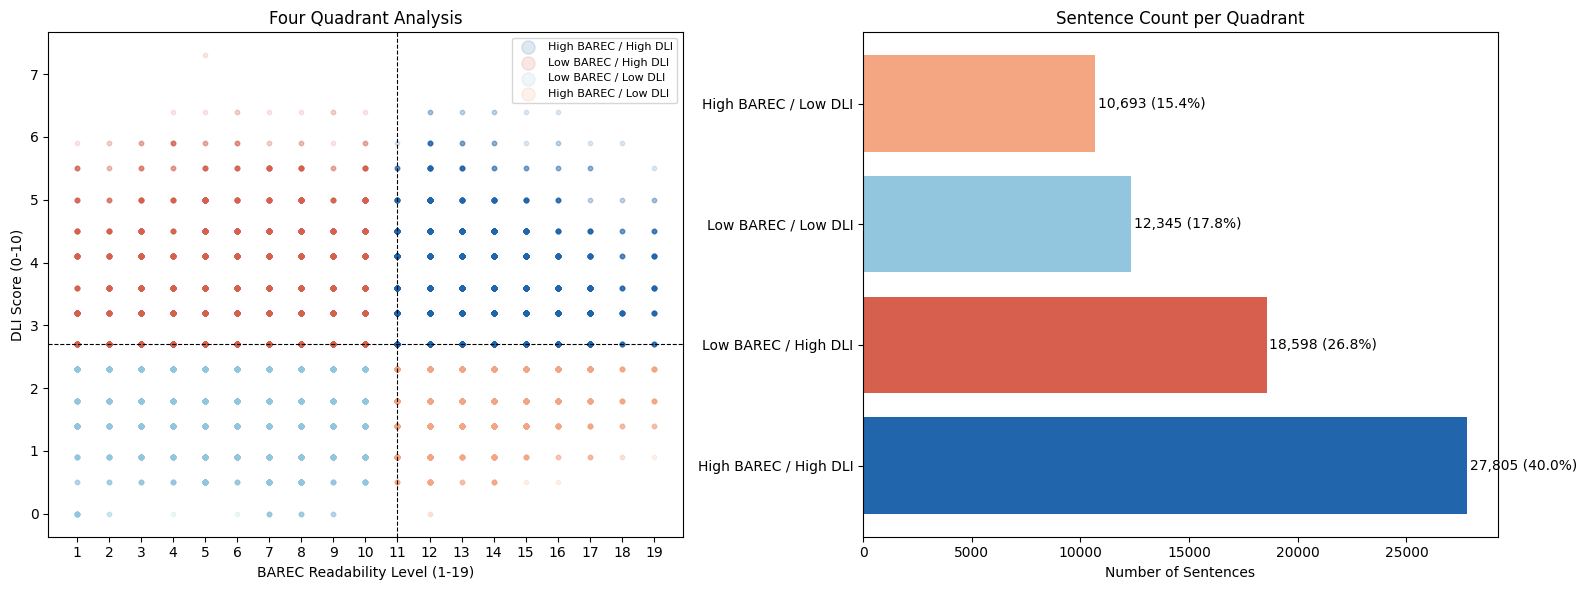

Saved!


In [ ]:
# recompute quadrants on current df_full
dli_median = df_full['DLI_10'].median()
barec_median = df_full['Readability_Level_19'].median()

df_full['Quadrant'] = 'Low BAREC / Low DLI'
df_full.loc[(df_full['Readability_Level_19'] >= barec_median) & (df_full['DLI_10'] >= dli_median), 'Quadrant'] = 'High BAREC / High DLI'
df_full.loc[(df_full['Readability_Level_19'] < barec_median) & (df_full['DLI_10'] >= dli_median), 'Quadrant'] = 'Low BAREC / High DLI'
df_full.loc[(df_full['Readability_Level_19'] >= barec_median) & (df_full['DLI_10'] < dli_median), 'Quadrant'] = 'High BAREC / Low DLI'

print(f"Medians — BAREC: {barec_median}, DLI_10: {dli_median}")
print(df_full['Quadrant'].value_counts())

# plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# scatter with quadrant coloring
colors = {
    'High BAREC / High DLI': '#2166ac',
    'Low BAREC / High DLI': '#d6604d',
    'Low BAREC / Low DLI': '#92c5de',
    'High BAREC / Low DLI': '#f4a582'
}

for quadrant, color in colors.items():
    mask = df_full['Quadrant'] == quadrant
    axes[0].scatter(
        df_full[mask]['Readability_Level_19'],
        df_full[mask]['DLI_10'],
        alpha=0.15, s=10, color=color, label=quadrant
    )

axes[0].axvline(barec_median, color='black', linestyle='--', linewidth=0.8)
axes[0].axhline(dli_median, color='black', linestyle='--', linewidth=0.8)
axes[0].set_xlabel('BAREC Readability Level (1-19)')
axes[0].set_ylabel('DLI Score (0-10)')
axes[0].set_title('Four Quadrant Analysis')
axes[0].set_xticks(range(1, 20))
axes[0].legend(loc='upper right', fontsize=8, markerscale=3)

# quadrant counts bar chart
quadrant_counts = df_full['Quadrant'].value_counts()
bars = axes[1].barh(quadrant_counts.index, quadrant_counts.values,
                    color=[colors[q] for q in quadrant_counts.index])
axes[1].set_xlabel('Number of Sentences')
axes[1].set_title('Sentence Count per Quadrant')
for i, (idx, val) in enumerate(quadrant_counts.items()):
    pct = val / len(df_full) * 100
    axes[1].text(val + 100, i, f'{val:,} ({pct:.1f}%)', va='center')

plt.tight_layout()
plt.savefig('dli_quadrant_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [82]:
feature_cols = ['DLP', 'Dot_Load_Ratio', 'OVL', 'Similar_Shape_Density',
                'PSC_Density', 'Lexical_Difficulty', 'Homograph_Risk',
                'Avg_Morphological_Complexity']

level_features = df_full.groupby('Readability_Level_19')[feature_cols].mean()
print(level_features.round(3))

                        DLP  Dot_Load_Ratio    OVL  Similar_Shape_Density  \
Readability_Level_19                                                        
1                     0.312           0.450  0.236                  0.531   
2                     0.372           0.544  0.232                  0.556   
3                     0.310           0.483  0.204                  0.487   
4                     0.341           0.512  0.199                  0.503   
5                     0.327           0.524  0.246                  0.467   
6                     0.349           0.543  0.278                  0.516   
7                     0.326           0.503  0.196                  0.495   
8                     0.340           0.526  0.164                  0.494   
9                     0.358           0.564  0.161                  0.514   
10                    0.355           0.548  0.146                  0.499   
11                    0.343           0.537  0.162                  0.486   

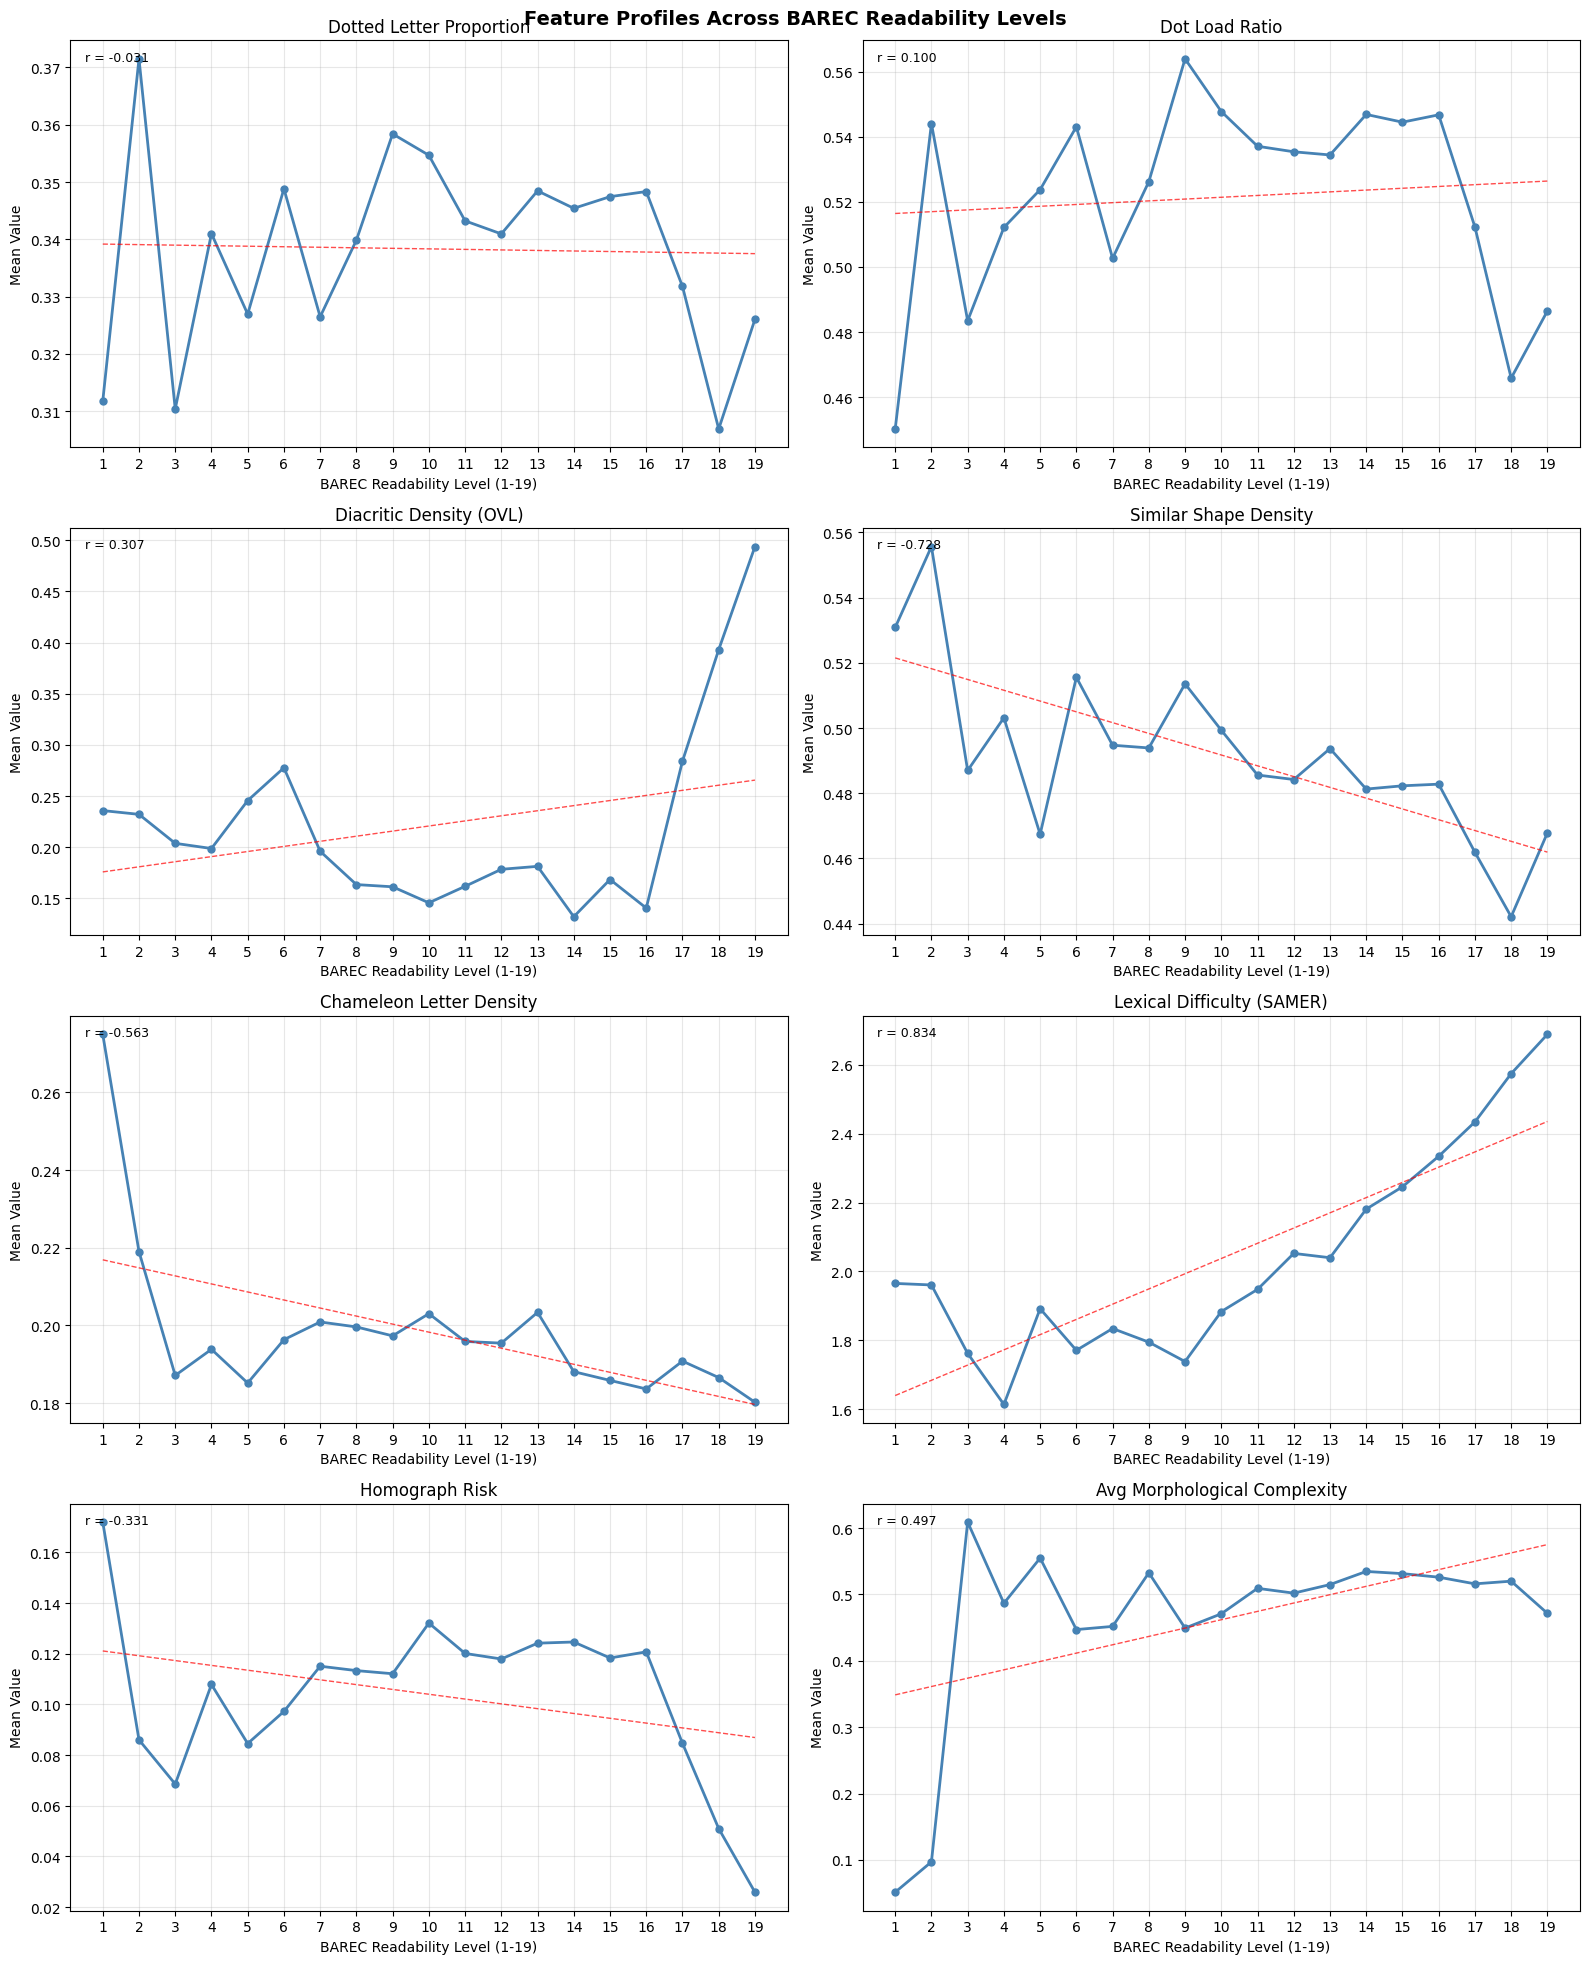

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

feature_labels = {
    'DLP': 'Dotted Letter Proportion',
    'Dot_Load_Ratio': 'Dot Load Ratio',
    'OVL': 'Diacritic Density (OVL)',
    'Similar_Shape_Density': 'Similar Shape Density',
    'PSC_Density': 'Chameleon Letter Density',
    'Lexical_Difficulty': 'Lexical Difficulty (SAMER)',
    'Homograph_Risk': 'Homograph Risk',
    'Avg_Morphological_Complexity': 'Avg Morphological Complexity'
}

for i, (col, label) in enumerate(feature_labels.items()):
    axes[i].plot(level_features.index, level_features[col], 
                 'o-', color='steelblue', linewidth=2, markersize=5)
    axes[i].set_xlabel('BAREC Readability Level (1-19)')
    axes[i].set_ylabel('Mean Value')
    axes[i].set_title(label)
    axes[i].set_xticks(range(1, 20))
    axes[i].grid(True, alpha=0.3)
    
    # add trend line
    z = np.polyfit(level_features.index, level_features[col], 1)
    p = np.poly1d(z)
    axes[i].plot(level_features.index, p(level_features.index), 
                 '--', color='red', linewidth=1, alpha=0.7, label=f'trend')
    
    # correlation
    corr, _ = stats.pearsonr(level_features.index, level_features[col])
    axes[i].text(0.02, 0.95, f'r = {corr:.3f}', transform=axes[i].transAxes, fontsize=9)

plt.suptitle('Feature Profiles Across BAREC Readability Levels', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dli_feature_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.1 Worked Example (Table 4, Section 3.5)

Verifies the DLI score for the worked example sentence in the thesis.

In [ ]:
# Worked example verification - reproduces Table 4 (Section 3.5)
# Requires df_full to be loaded first

def strip_diacritics(text):
    import re
    return re.sub(r'[\u064B-\u0652]', '', text)

target = strip_diacritics('طفوتُ على صفحته')
row = df_full[df_full['Sentence'].apply(strip_diacritics).str.contains(target, regex=False)].iloc[0]

features = {
    'DLP': row['DLP'], 'DLR': row['Dot_Load_Ratio'],
    'OVL': row['OVL'], 'SSD': row['Similar_Shape_Density'],
    'PSC': row['PSC_Density'], 'LD': row['Lexical_Difficulty'],
    'HR': row['Homograph_Risk'], 'MC': row['Avg_Morphological_Complexity']
}

thresholds = {
    'DLP': [0.30, 0.50], 'DLR': [0.50, 0.70, 1.00],
    'OVL': [0.10, 0.40, 0.80], 'SSD': [0.40, 0.60, 0.80],
    'PSC': [0.15, 0.25], 'LD': [1.50, 2.50, 3.50],
    'HR': [0.10, 0.30], 'MC': [0.40, 0.70, 1.20, 2.50]
}

total = 0
for feat, val in features.items():
    score = sum(1 for t in thresholds[feat] if val > t)
    total += score
    print(f"{feat}: value={val:.3f}, score={score}")

print(f"\nRaw DLI: {total}")
print(f"DLI_norm: {1 + (total/16)*4:.3f}")


## 4. LLM Proxy Evaluation

### 4.1 Batch 1 - GPT (scale 0-10, no expert persona, pilot n=121)

> **WARNING:** Running API cells costs credits. Load from saved CSVs where possible.

In [87]:
# load sentences
df_eval = pd.read_csv('../results/validation/llm_eval_sentences_with_quadrant.csv')
sentences = df_eval['Statement'].tolist()
print(f"Sentences loaded: {len(sentences)}")

# load df_full for few-shot examples
few_shot_examples = get_few_shot_examples(df_full)

# get few-shot examples EXCLUDING eval sentences
eval_sentences = set(df_eval['Statement'])
few_shot_examples = get_few_shot_examples(
    df_full[~df_full['Sentence'].isin(eval_sentences)],
    n_per_band=2
)

Sentences loaded: 120


In [ ]:
# run
# print("\nRunning Zero-Shot Pure...")
# zs_pure = run_experiment(sentences, lambda s: ZERO_SHOT_PURE.format(sentence=s))
# zs_pure.to_csv('../results/validation/GPT/Batch_1/results_zeroshot_pure.csv', index=False, encoding='utf-8-sig')

# print("\nRunning Zero-Shot Prompted/Structured/Guided...")
# zs_prompted = run_experiment(sentences, lambda s: ZERO_SHOT_PROMPTED.format(sentence=s))
# zs_prompted.to_csv('../results/validation/GPT/Batch_1/results_zeroshot_prompted.csv', index=False, encoding='utf-8-sig')

# print("\nRunning Few-Shot...")
# fs = run_experiment(sentences, lambda s: build_few_shot_prompt(few_shot_examples, s))
# fs.to_csv('../results/validation/GPT/Batch_1/results_fewshot.csv', index=False, encoding='utf-8-sig')

# print("\nAll done!")


Running Zero-Shot Pure...
Raw response 1: '{"score": 4, "label": "MODERATE", "explanation": "Vocalization (short vowels and sukun) aids decoding, but the shadda (consonant doubling), the hamza in إِنْ, and visually similar consonants (e.g. ذ/ز/د) together with repeated root forms increase visual and phonological confusion for dyslexic readers."}'
Raw response 2: '{"score": 7, "label": "HIGH", "explanation": "Multiple long, multisyllabic and morphologically complex words (e.g., اللاحق، عناصر، الخاصية، المميزة), unfamiliar foreign names (ماري وبيير كوري), and absence of diacritics increase orthographic decoding demands, making the sentence relatively difficult for Arabic dyslexic readers."}'
Raw response 3: '{"score": 3, "label": "LOW", "explanation": "The sentence is fully vowelled and short so decoding is relatively easy; only mild difficulty may arise from the hamza in بِأَبْوَابِهَا and the shadda/doubled consonant in فَغُلِّقَتْ."}'
Progress: 10/121
Progress: 20/121
Progress: 30/12

In [ ]:
# load results
zs_prompted = pd.read_csv('../results/validation/GPT/Batch_1/results_zeroshot_prompted.csv')
zs_pure = pd.read_csv('../results/validation/GPT/Batch_1/results_zeroshot_pure.csv')
fs = pd.read_csv('../results/validation/GPT/Batch_1/results_fewshot.csv')


# compare all three
compare_with_dli(zs_pure, df_full, label='Zero-Shot Pure')


In [ ]:
compare_with_dli(zs_prompted, df_full, dli_col='DLI_10', label='Zero-Shot Prompted')

In [72]:
compare_with_dli(fs, df_full, dli_col='DLI_10', label='Few-Shot')


=== Few-Shot ===
Pearson r:     0.0600  (p=0.5130)
Spearman r:    0.0851  (p=0.3531)
MAE:           1.8033
Mean Diff:     0.1570  (DLI - LLM, positive = DLI scores higher)
LLM mean:      2.7868
DLI mean:      2.9438
N:             121


,Sentence,LLM_Score,LLM_Label,LLM_Explanation,DLI_10
0,فَإِنْ كَذَبَنِي فَكَذِّبُوهُ .,4.0,MODERATE,"Short and fully vowelled which aids decoding, ...",6.4
1,وكشف عمل ماري وبيير كوري اللاحق عن أن ثمة عناص...,3.1,MODERATE,Moderate difficulty: the sentence is moderatel...,2.7
2,ثُمَّ أَمَرَ بِأَبْوَابِهَا فَغُلِّقَتْ ،,1.6,LOW,"Short, fully vowelled sentence with simple voc...",4.5
3,عند انصهار فيوز يمكن الاستعاضة عنه بسلك لتشغيل...,4.0,MODERATE,Moderate decoding difficulty due to technical ...,3.2
4,ومع ذلك، فإنه لا يتم عرض العلم في كثير من الأح...,3.8,MODERATE,Moderate difficulty: the sentence uses formal ...,3.2
...,...,...,...,...,...
116,وقد استغرق الأمر مليارات السنين كي تصل الحياة ...,3.0,MODERATE,Moderate decoding difficulty due to several lo...,2.3
117,وتطورت واجهات المستخدم العاملة عليه لتدعم كل ل...,1.7,LOW,Short to moderate length with mostly common vo...,2.3
118,هلا ملأت هذا النموذج ؟,2.1,LOW,"The sentence is short with common vocabulary, ...",1.4
119,كما امتدت القروض والمنح والمساعدات التي قدمتها...,1.8,LOW,"Common vocabulary, regular syntax with predict...",1.4


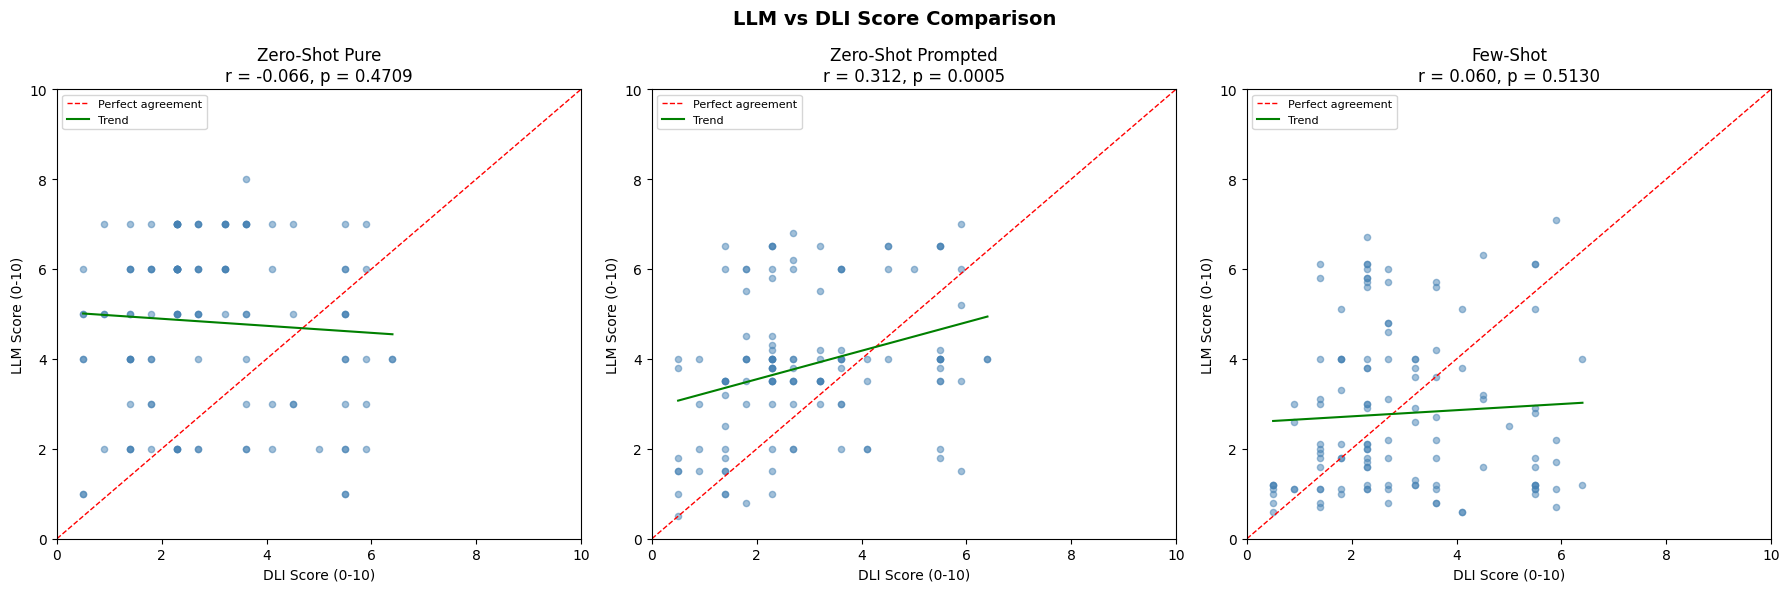

Saved!


In [76]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

experiments = [
    ('Zero-Shot Pure', zs_pure, -0.0662, 0.4709),
    ('Zero-Shot Prompted', zs_prompted, 0.3117, 0.0005),
    ('Few-Shot', fs, 0.0600, 0.5130)
]

for ax, (label, df_exp, r, p) in zip(axes, experiments):
    # merge with dli
    merged = df_exp.merge(
        df_full[['Sentence', 'DLI_10']].drop_duplicates(subset='Sentence'),
        on='Sentence', how='left'
    ).dropna(subset=['LLM_Score', 'DLI_10'])
    
    ax.scatter(merged['DLI_10'], merged['LLM_Score'], 
               alpha=0.5, s=20, color='steelblue')
    
    # perfect agreement line
    ax.plot([0, 10], [0, 10], 'r--', linewidth=1, label='Perfect agreement')
    
    # regression line
    z = np.polyfit(merged['DLI_10'], merged['LLM_Score'], 1)
    p_line = np.poly1d(z)
    x_range = np.linspace(merged['DLI_10'].min(), merged['DLI_10'].max(), 100)
    ax.plot(x_range, p_line(x_range), 'g-', linewidth=1.5, label='Trend')
    
    ax.set_xlabel('DLI Score (0-10)')
    ax.set_ylabel('LLM Score (0-10)')
    ax.set_title(f'{label}\nr = {r:.3f}, p = {p:.4f}')
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.legend(fontsize=8)

plt.suptitle('LLM vs DLI Score Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/llm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

### 4.2 Batch 2 - GPT (scale 1-5, expert persona, pilot n=121)

In [90]:
# load sentences
df_eval = pd.read_csv('../results/validation/llm_eval_sentences_with_dli_norm.csv')
sentences = df_eval['Statement'].tolist()
print(f"Sentences loaded: {len(sentences)}")

# load df_barec_annotated for few-shot examples
df_barec_annotated = pd.read_csv('../results/annotated/barec_annotated.csv')
few_shot_examples = get_few_shot_examples(df_barec_annotated)

# get few-shot examples EXCLUDING eval sentences
eval_sentences = set(df_eval['Statement'])
few_shot_examples = get_few_shot_examples(
    df_barec_annotated[~df_barec_annotated['Sentence'].isin(eval_sentences)],
    n_per_band=2
)

Sentences loaded: 120


In [ ]:
# # run
# print("\nRunning Zero-Shot Pure...")
# zs_pure_v2 = await run_experiment_async(sentences, lambda s: ZERO_SHOT_PURE.format(sentence=s), max_concurrent=20)
# zs_pure_v2.to_csv('../results/validation/GPT/Batch_2/results_zeroshot_pure_v2.csv', index=False, encoding='utf-8-sig')

# print("\nRunning Zero-Shot Prompted...")
# zs_prompted_v2 = await run_experiment_async(sentences, lambda s: ZERO_SHOT_PROMPTED.format(sentence=s), max_concurrent=20)
# zs_prompted_v2.to_csv('../results/validation/GPT/Batch_2/results_zeroshot_prompted_v2.csv', index=False, encoding='utf-8-sig')

# print("\nRunning Few-Shot...")
# fs_v2 = await run_experiment_async(sentences, lambda s: build_few_shot_prompt(few_shot_examples, s), max_concurrent=20)
# fs_v2.to_csv('../results/validation/GPT/Batch_2/results_fewshot_v2.csv', index=False, encoding='utf-8-sig')

# print("\nAll done!")


Running Zero-Shot Pure...
Progress: 20/120
Progress: 10/120
Progress: 30/120
Progress: 40/120
Progress: 50/120
Progress: 60/120
Progress: 70/120
Progress: 80/120
Progress: 90/120
Progress: 100/120
Progress: 110/120
Progress: 120/120

Running Zero-Shot Prompted...
Progress: 10/120
Progress: 20/120
Progress: 30/120
Progress: 50/120
Progress: 40/120
Progress: 60/120
Progress: 70/120
Progress: 80/120
Progress: 90/120
Progress: 100/120
Progress: 110/120
Progress: 120/120

Running Few-Shot...
Progress: 10/120
Progress: 20/120
Progress: 30/120
Progress: 40/120
Progress: 50/120
Progress: 60/120
Progress: 70/120
Progress: 80/120
Progress: 90/120
Progress: 100/120
Progress: 110/120
Progress: 120/120

All done!


In [91]:
# load v2 results
zs_pure_v2 = pd.read_csv('../results/validation/GPT/Batch_2/results_zeroshot_pure_v2.csv')
zs_prompted_v2 = pd.read_csv('../results/validation/GPT/Batch_2/results_zeroshot_prompted_v2.csv')
fs_v2 = pd.read_csv('../results/validation/GPT/Batch_2/results_fewshot_v2.csv')

In [54]:
# compare all three against DLI_1_5 and DLI_1_5_norm
compare_with_dli(zs_pure_v2, df_full, label='Zero-Shot Pure v2')


=== Zero-Shot Pure v2 ===
Pearson r:     0.0253  (p=0.7838)
Spearman r:    0.0640  (p=0.4877)
MAE:           1.0167
Mean Diff:     -0.4483  (DLI - LLM, positive = DLI scores higher)
LLM mean:      2.6250
DLI mean:      2.1767
N:             120


,Statement,LLM_Score,LLM_Label,LLM_Explanation,DLI_1_5
0,فَإِنْ كَذَبَنِي فَكَذِّبُوهُ .,2,EASY,"full diacritics, short words, familiar lexicon...",3.5
1,وكشف عمل ماري وبيير كوري اللاحق عن أن ثمة عناص...,4,HARD,long multisyllabic words; complex morphology (...,2.1
2,ثُمَّ أَمَرَ بِأَبْوَابِهَا فَغُلِّقَتْ ،,2,EASY,"full diacritics, clear word boundaries, common...",2.8
3,عند انصهار فيوز يمكن الاستعاضة عنه بسلك لتشغيل...,4,HARD,"technical loanword (فيوز), morphologically com...",2.3
4,ومع ذلك، فإنه لا يتم عرض العلم في كثير من الأح...,3,MODERATE,"medium sentence length, passive construction (...",2.3
...,...,...,...,...,...
115,وقد استغرق الأمر مليارات السنين كي تصل الحياة ...,3,MODERATE,long multisyllabic words; clitic attachments (...,1.9
116,وتطورت واجهات المستخدم العاملة عليه لتدعم كل ل...,3,MODERATE,"absence of short-vowel diacritics, concatenate...",1.9
117,هلا ملأت هذا النموذج ؟,3,MODERATE,short length; common vocabulary; absent diacri...,1.5
118,كما امتدت القروض والمنح والمساعدات التي قدمتها...,4,HARD,"multisyllabic/morphologically complex words, i...",1.5


In [55]:
compare_with_dli(zs_pure_v2, df_eval, dli_col='DLI_1_5_norm', label='Zero-Shot Pure v2')


=== Zero-Shot Pure v2 ===
Pearson r:     0.0197  (p=0.8307)
Spearman r:    0.0640  (p=0.4877)
MAE:           1.0383
Mean Diff:     -0.0150  (DLI - LLM, positive = DLI scores higher)
LLM mean:      2.6250
DLI mean:      2.6100
N:             120


,Statement,LLM_Score,LLM_Label,LLM_Explanation,DLI_1_5_norm
0,فَإِنْ كَذَبَنِي فَكَذِّبُوهُ .,2,EASY,"full diacritics, short words, familiar lexicon...",4.5
1,وكشف عمل ماري وبيير كوري اللاحق عن أن ثمة عناص...,4,HARD,long multisyllabic words; complex morphology (...,2.5
2,ثُمَّ أَمَرَ بِأَبْوَابِهَا فَغُلِّقَتْ ،,2,EASY,"full diacritics, clear word boundaries, common...",3.5
3,عند انصهار فيوز يمكن الاستعاضة عنه بسلك لتشغيل...,4,HARD,"technical loanword (فيوز), morphologically com...",2.8
4,ومع ذلك، فإنه لا يتم عرض العلم في كثير من الأح...,3,MODERATE,"medium sentence length, passive construction (...",2.8
...,...,...,...,...,...
115,وقد استغرق الأمر مليارات السنين كي تصل الحياة ...,3,MODERATE,long multisyllabic words; clitic attachments (...,2.2
116,وتطورت واجهات المستخدم العاملة عليه لتدعم كل ل...,3,MODERATE,"absence of short-vowel diacritics, concatenate...",2.2
117,هلا ملأت هذا النموذج ؟,3,MODERATE,short length; common vocabulary; absent diacri...,1.8
118,كما امتدت القروض والمنح والمساعدات التي قدمتها...,4,HARD,"multisyllabic/morphologically complex words, i...",1.8


In [56]:
compare_with_dli(zs_prompted_v2, df_eval, label='Zero-Shot Prompted v2')


=== Zero-Shot Prompted v2 ===
Pearson r:     0.3445  (p=0.0001)
Spearman r:    0.3788  (p=0.0000)
MAE:           0.9367
Mean Diff:     -0.5650  (DLI - LLM, positive = DLI scores higher)
LLM mean:      2.7417
DLI mean:      2.1767
N:             120


,Statement,LLM_Score,LLM_Label,LLM_Explanation,DLI_1_5
0,فَإِنْ كَذَبَنِي فَكَذِّبُوهُ .,3,MODERATE,"high diacritic density, cluster of dot-heavy l...",3.5
1,وكشف عمل ماري وبيير كوري اللاحق عن أن ثمة عناص...,3,MODERATE,"unvowelized ambiguity; dot-heavy letters (ث, ب...",2.1
2,ثُمَّ أَمَرَ بِأَبْوَابِهَا فَغُلِّقَتْ ،,4,HARD,"high diacritic density (shadda/sukūn/fatha), d...",2.8
3,عند انصهار فيوز يمكن الاستعاضة عنه بسلك لتشغيل...,4,HARD,"unvowelized/ambiguous (no diacritics), dot-hea...",2.3
4,ومع ذلك، فإنه لا يتم عرض العلم في كثير من الأح...,4,HARD,"unvowelized ambiguity ('عرض'), dot-heavy lette...",2.3
...,...,...,...,...,...
115,وقد استغرق الأمر مليارات السنين كي تصل الحياة ...,3,MODERATE,dot-heavy letters (ق، ض، ت، ذ); shape-changing...,1.9
116,وتطورت واجهات المستخدم العاملة عليه لتدعم كل ل...,2,EASY,unvowelized (ambiguous); high-frequency vocabu...,1.9
117,هلا ملأت هذا النموذج ؟,1,VERY_EASY,short common words; no diacritics; low dot den...,1.5
118,كما امتدت القروض والمنح والمساعدات التي قدمتها...,3,MODERATE,"dot-heavy letters (ق ض ن ي), shape-shifting le...",1.5


In [57]:
compare_with_dli(zs_prompted_v2, df_eval, dli_col='DLI_1_5_norm', label='Zero-Shot Prompted v2')


=== Zero-Shot Prompted v2 ===
Pearson r:     0.3464  (p=0.0001)
Spearman r:    0.3788  (p=0.0000)
MAE:           0.8350
Mean Diff:     -0.1317  (DLI - LLM, positive = DLI scores higher)
LLM mean:      2.7417
DLI mean:      2.6100
N:             120


,Statement,LLM_Score,LLM_Label,LLM_Explanation,DLI_1_5_norm
0,فَإِنْ كَذَبَنِي فَكَذِّبُوهُ .,3,MODERATE,"high diacritic density, cluster of dot-heavy l...",4.5
1,وكشف عمل ماري وبيير كوري اللاحق عن أن ثمة عناص...,3,MODERATE,"unvowelized ambiguity; dot-heavy letters (ث, ب...",2.5
2,ثُمَّ أَمَرَ بِأَبْوَابِهَا فَغُلِّقَتْ ،,4,HARD,"high diacritic density (shadda/sukūn/fatha), d...",3.5
3,عند انصهار فيوز يمكن الاستعاضة عنه بسلك لتشغيل...,4,HARD,"unvowelized/ambiguous (no diacritics), dot-hea...",2.8
4,ومع ذلك، فإنه لا يتم عرض العلم في كثير من الأح...,4,HARD,"unvowelized ambiguity ('عرض'), dot-heavy lette...",2.8
...,...,...,...,...,...
115,وقد استغرق الأمر مليارات السنين كي تصل الحياة ...,3,MODERATE,dot-heavy letters (ق، ض، ت، ذ); shape-changing...,2.2
116,وتطورت واجهات المستخدم العاملة عليه لتدعم كل ل...,2,EASY,unvowelized (ambiguous); high-frequency vocabu...,2.2
117,هلا ملأت هذا النموذج ؟,1,VERY_EASY,short common words; no diacritics; low dot den...,1.8
118,كما امتدت القروض والمنح والمساعدات التي قدمتها...,3,MODERATE,"dot-heavy letters (ق ض ن ي), shape-shifting le...",1.8


In [58]:
compare_with_dli(fs_v2, df_eval, dli_col='DLI_1_5', label='Few-Shot v2')


=== Few-Shot v2 ===
Pearson r:     0.2818  (p=0.0018)
Spearman r:    0.3075  (p=0.0006)
MAE:           0.7250
Mean Diff:     -0.2417  (DLI - LLM, positive = DLI scores higher)
LLM mean:      2.4183
DLI mean:      2.1767
N:             120


,Statement,LLM_Score,LLM_Label,LLM_Explanation,DLI_1_5
0,فَإِنْ كَذَبَنِي فَكَذِّبُوهُ .,2.6,MODERATE,"fully vocalized (diacritics), short length, hi...",3.5
1,وكشف عمل ماري وبيير كوري اللاحق عن أن ثمة عناص...,3.0,MODERATE,long multisyllabic words; low-frequency vocabu...,2.1
2,ثُمَّ أَمَرَ بِأَبْوَابِهَا فَغُلِّقَتْ ،,1.9,EASY,"short sentence; full diacritics (vowelization,...",2.8
3,عند انصهار فيوز يمكن الاستعاضة عنه بسلك لتشغيل...,3.0,MODERATE,technical loanword 'فيوز' (unfamiliar orthogra...,2.3
4,ومع ذلك، فإنه لا يتم عرض العلم في كثير من الأح...,3.0,MODERATE,absent diacritics; passive construction ('لا ي...,2.3
...,...,...,...,...,...
115,وقد استغرق الأمر مليارات السنين كي تصل الحياة ...,2.8,MODERATE,multisyllabic words; morphological complexity ...,1.9
116,وتطورت واجهات المستخدم العاملة عليه لتدعم كل ل...,3.0,MODERATE,"multisyllabic words, morphological complexity ...",1.9
117,هلا ملأت هذا النموذج ؟,1.5,VERY_EASY,short length; high-frequency words; simple syn...,1.5
118,كما امتدت القروض والمنح والمساعدات التي قدمتها...,2.0,EASY,high-frequency vocabulary; familiar collocatio...,1.5


In [59]:
compare_with_dli(fs_v2, df_eval, dli_col='DLI_1_5_norm', label='Few-Shot v2')


=== Few-Shot v2 ===
Pearson r:     0.2831  (p=0.0017)
Spearman r:    0.3075  (p=0.0006)
MAE:           0.7533
Mean Diff:     0.1917  (DLI - LLM, positive = DLI scores higher)
LLM mean:      2.4183
DLI mean:      2.6100
N:             120


,Statement,LLM_Score,LLM_Label,LLM_Explanation,DLI_1_5_norm
0,فَإِنْ كَذَبَنِي فَكَذِّبُوهُ .,2.6,MODERATE,"fully vocalized (diacritics), short length, hi...",4.5
1,وكشف عمل ماري وبيير كوري اللاحق عن أن ثمة عناص...,3.0,MODERATE,long multisyllabic words; low-frequency vocabu...,2.5
2,ثُمَّ أَمَرَ بِأَبْوَابِهَا فَغُلِّقَتْ ،,1.9,EASY,"short sentence; full diacritics (vowelization,...",3.5
3,عند انصهار فيوز يمكن الاستعاضة عنه بسلك لتشغيل...,3.0,MODERATE,technical loanword 'فيوز' (unfamiliar orthogra...,2.8
4,ومع ذلك، فإنه لا يتم عرض العلم في كثير من الأح...,3.0,MODERATE,absent diacritics; passive construction ('لا ي...,2.8
...,...,...,...,...,...
115,وقد استغرق الأمر مليارات السنين كي تصل الحياة ...,2.8,MODERATE,multisyllabic words; morphological complexity ...,2.2
116,وتطورت واجهات المستخدم العاملة عليه لتدعم كل ل...,3.0,MODERATE,"multisyllabic words, morphological complexity ...",2.2
117,هلا ملأت هذا النموذج ؟,1.5,VERY_EASY,short length; high-frequency words; simple syn...,1.8
118,كما امتدت القروض والمنح والمساعدات التي قدمتها...,2.0,EASY,high-frequency vocabulary; familiar collocatio...,1.8


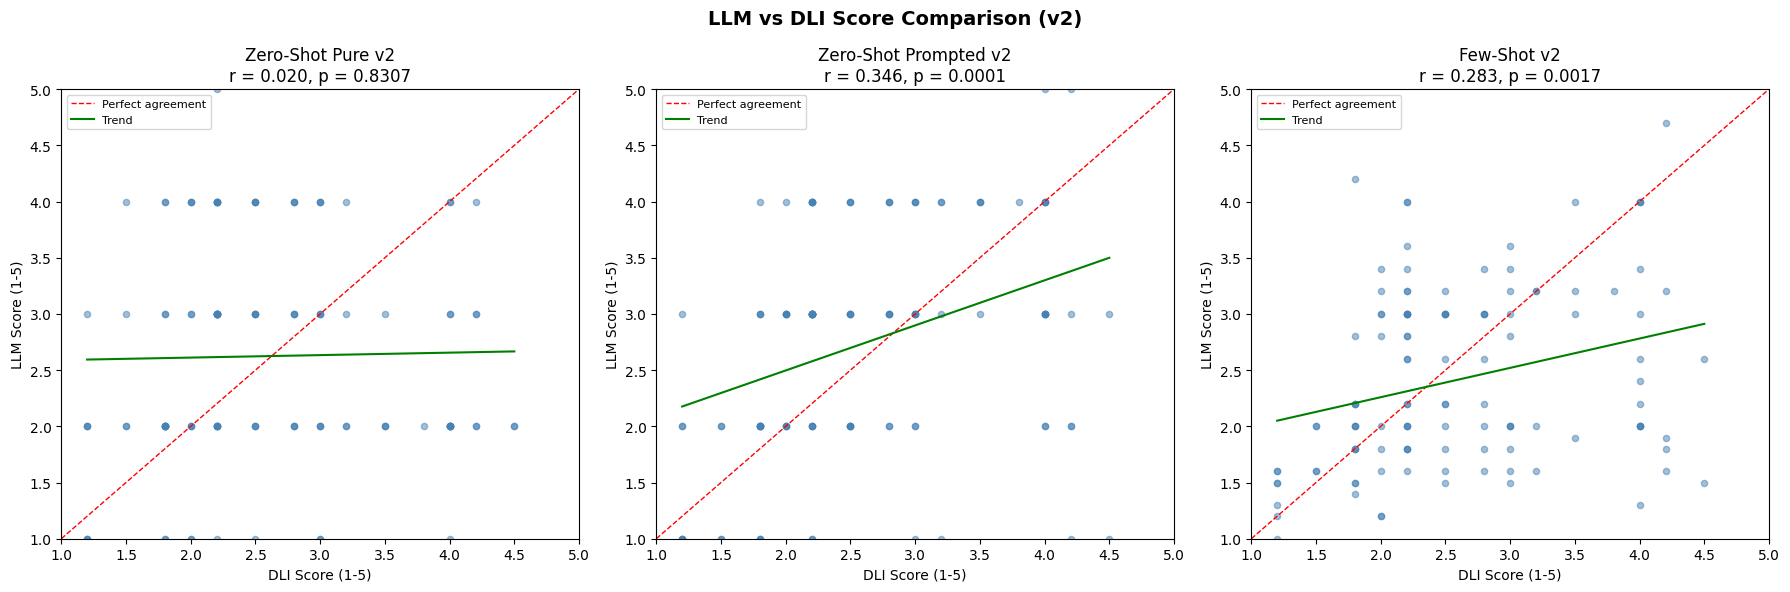

Saved!


In [64]:
# plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

experiments_v2 = [
    ('Zero-Shot Pure v2', zs_pure_v2),
    ('Zero-Shot Prompted v2', zs_prompted_v2),
    ('Few-Shot v2', fs_v2)
]

for ax, (label, df_exp) in zip(axes, experiments_v2):
    merged = df_exp.merge(
        df_eval[['Statement', 'DLI_1_5_norm']].drop_duplicates(subset='Statement'),
        on='Statement', how='left'
    ).dropna(subset=['LLM_Score', 'DLI_1_5_norm'])

    r, p = stats.pearsonr(merged['LLM_Score'], merged['DLI_1_5_norm'])

    ax.scatter(merged['DLI_1_5_norm'], merged['LLM_Score'],
               alpha=0.5, s=20, color='steelblue')
    ax.plot([1, 5], [1, 5], 'r--', linewidth=1, label='Perfect agreement')

    z = np.polyfit(merged['DLI_1_5_norm'], merged['LLM_Score'], 1)
    p_line = np.poly1d(z)
    x_range = np.linspace(merged['DLI_1_5_norm'].min(), merged['DLI_1_5_norm'].max(), 100)
    ax.plot(x_range, p_line(x_range), 'g-', linewidth=1.5, label='Trend')

    ax.set_xlabel('DLI Score (1-5)')
    ax.set_ylabel('LLM Score (1-5)')
    ax.set_title(f'{label}\nr = {r:.3f}, p = {p:.4f}')
    ax.set_xlim(1, 5)
    ax.set_ylim(1, 5)
    ax.legend(fontsize=8)

plt.suptitle('LLM vs DLI Score Comparison (v2)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/llm_comparison_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

### 4.3 Batch 2 - Fanar (scale 1-5, expert persona, pilot n=121)

In [92]:
# load sentences
df_eval = pd.read_csv('../results/validation/llm_eval_sentences_with_dli_norm.csv')
sentences = df_eval['Statement'].tolist()
print(f"Sentences loaded: {len(sentences)}")

# load df_full for few-shot examples
df_full = pd.read_csv('../results/annotated/barec_annotated.csv')
few_shot_examples = get_few_shot_examples(df_full)

# get few-shot examples EXCLUDING eval sentences
eval_sentences = set(df_eval['Statement'])
few_shot_examples = get_few_shot_examples(
    df_full[~df_full['Sentence'].isin(eval_sentences)],
    n_per_band=2
)

Sentences loaded: 120


In [ ]:
# print("Running Fanar Zero-Shot Pure...")
# fanar_zs_pure = await run_experiment_fanar(
#     sentences, lambda s: ZERO_SHOT_PURE.format(sentence=s),
#     model="Fanar", max_concurrent=3, delay=1.5)
# fanar_zs_pure.to_csv('../results/validation/Fanar/results_fanar_zeroshot_pure.csv', index=False, encoding='utf-8-sig')

# print("Running Fanar Zero-Shot Prompted...")
# fanar_zs_prompted = await run_experiment_fanar(
#     sentences, lambda s: ZERO_SHOT_PROMPTED.format(sentence=s),
#     model="Fanar", max_concurrent=3, delay=1.5)
# fanar_zs_prompted.to_csv('../results/validation/Fanar/results_fanar_zeroshot_prompted.csv', index=False, encoding='utf-8-sig')

# print("Running Fanar Few-Shot...")
# fanar_fs = await run_experiment_fanar(
#     sentences, lambda s: build_few_shot_prompt(few_shot_examples, s),
#     model="Fanar", max_concurrent=3, delay=1.5)
# fanar_fs.to_csv('../results/validation/Fanar/results_fanar_fewshot.csv', index=False, encoding='utf-8-sig')

# print("All done!")

Running Fanar Zero-Shot Pure...
Running Fanar Zero-Shot Prompted...
Running Fanar Few-Shot...
All done!


In [93]:
# load Fanar results
zs_pure_fanar = pd.read_csv('../results/validation/Fanar/results_fanar_zeroshot_pure.csv')
zs_prompted_fanar = pd.read_csv('../results/validation/Fanar/results_fanar_zeroshot_prompted.csv')
fs_fanar = pd.read_csv('../results/validation/Fanar/results_fanar_fewshot.csv')

In [92]:
# compare all three against DLI_1_5 and DLI_1_5_norm
compare_with_dli(zs_pure_fanar, df_eval, label='Zero-Shot Pure Fanar')


=== Zero-Shot Pure Fanar ===
Pearson r:     0.0774  (p=0.4007)
Spearman r:    0.1274  (p=0.1657)
MAE:           1.0950
Mean Diff:     -0.7233  (DLI - LLM, positive = DLI scores higher)
LLM mean:      2.9000
DLI mean:      2.1767
N:             120


,Statement,LLM_Score,LLM_Label,LLM_Explanation,DLI_1_5
0,فَإِنْ كَذَبَنِي فَكَذِّبُوهُ .,3,MODERATE,"Complex diacritics, vowel length ambiguity, co...",3.5
1,وكشف عمل ماري وبيير كوري اللاحق عن أن ثمة عناص...,4,HARD,Complex sentence structure; abstract concepts ...,2.1
2,ثُمَّ أَمَرَ بِأَبْوَابِهَا فَغُلِّقَتْ ،,3,MODERATE,"Complex diacritics (harakat), long vowels, con...",2.8
3,عند انصهار فيوز يمكن الاستعاضة عنه بسلك لتشغيل...,3,MODERATE,Complex sentence structure; technical vocabula...,2.3
4,ومع ذلك، فإنه لا يتم عرض العلم في كثير من الأح...,4,HARD,Complex sentence structure; abstract concepts ...,2.3
...,...,...,...,...,...
115,وقد استغرق الأمر مليارات السنين كي تصل الحياة ...,3,MODERATE,Complex sentence structure; abstract concepts ...,1.9
116,وتطورت واجهات المستخدم العاملة عليه لتدعم كل ل...,3,MODERATE,Complex sentence structure; unfamiliar technic...,1.9
117,هلا ملأت هذا النموذج ؟,2,EASY,"Short sentence, common words, clear vowel mark...",1.5
118,كما امتدت القروض والمنح والمساعدات التي قدمتها...,3,MODERATE,Complex sentence structure; unfamiliar technic...,1.5


In [93]:
compare_with_dli(zs_pure_fanar, df_eval, dli_col='DLI_1_5_norm', label='Zero-Shot Pure Fanar')


=== Zero-Shot Pure Fanar ===
Pearson r:     0.0831  (p=0.3667)
Spearman r:    0.1274  (p=0.1657)
MAE:           1.0383
Mean Diff:     -0.2900  (DLI - LLM, positive = DLI scores higher)
LLM mean:      2.9000
DLI mean:      2.6100
N:             120


,Statement,LLM_Score,LLM_Label,LLM_Explanation,DLI_1_5_norm
0,فَإِنْ كَذَبَنِي فَكَذِّبُوهُ .,3,MODERATE,"Complex diacritics, vowel length ambiguity, co...",4.5
1,وكشف عمل ماري وبيير كوري اللاحق عن أن ثمة عناص...,4,HARD,Complex sentence structure; abstract concepts ...,2.5
2,ثُمَّ أَمَرَ بِأَبْوَابِهَا فَغُلِّقَتْ ،,3,MODERATE,"Complex diacritics (harakat), long vowels, con...",3.5
3,عند انصهار فيوز يمكن الاستعاضة عنه بسلك لتشغيل...,3,MODERATE,Complex sentence structure; technical vocabula...,2.8
4,ومع ذلك، فإنه لا يتم عرض العلم في كثير من الأح...,4,HARD,Complex sentence structure; abstract concepts ...,2.8
...,...,...,...,...,...
115,وقد استغرق الأمر مليارات السنين كي تصل الحياة ...,3,MODERATE,Complex sentence structure; abstract concepts ...,2.2
116,وتطورت واجهات المستخدم العاملة عليه لتدعم كل ل...,3,MODERATE,Complex sentence structure; unfamiliar technic...,2.2
117,هلا ملأت هذا النموذج ؟,2,EASY,"Short sentence, common words, clear vowel mark...",1.8
118,كما امتدت القروض والمنح والمساعدات التي قدمتها...,3,MODERATE,Complex sentence structure; unfamiliar technic...,1.8


In [94]:
compare_with_dli(zs_prompted_fanar, df_eval, label='Zero-Shot Prompted Fanar')


=== Zero-Shot Prompted Fanar ===
Pearson r:     0.1713  (p=0.0613)
Spearman r:    0.2228  (p=0.0145)
MAE:           1.1533
Mean Diff:     -0.8483  (DLI - LLM, positive = DLI scores higher)
LLM mean:      3.0250
DLI mean:      2.1767
N:             120


,Statement,LLM_Score,LLM_Label,LLM_Explanation,DLI_1_5
0,فَإِنْ كَذَبَنِي فَكَذِّبُوهُ .,4,HARD,"Diacritics, dot-heavy letters (ث), shape-shift...",3.5
1,وكشف عمل ماري وبيير كوري اللاحق عن أن ثمة عناص...,4,HARD,"Diacritics, dot-heavy letters (ث), visually si...",2.1
2,ثُمَّ أَمَرَ بِأَبْوَابِهَا فَغُلِّقَتْ ،,4,HARD,"Diacritics, dot-heavy letters (ث), shape-shift...",2.8
3,عند انصهار فيوز يمكن الاستعاضة عنه بسلك لتشغيل...,4,HARD,"Diacritics, dot-heavy letters, shape-shifting ...",2.3
4,ومع ذلك، فإنه لا يتم عرض العلم في كثير من الأح...,4,HARD,"Diacritics, dot-heavy letters, visually simila...",2.3
...,...,...,...,...,...
115,وقد استغرق الأمر مليارات السنين كي تصل الحياة ...,3,MODERATE,"Diacritics, dot-heavy letters (ث), shape-shift...",1.9
116,وتطورت واجهات المستخدم العاملة عليه لتدعم كل ل...,3,MODERATE,"Diacritic density, dot-heavy letters (ت), shap...",1.9
117,هلا ملأت هذا النموذج ؟,2,EASY,"No diacritics, common letters, short word length.",1.5
118,كما امتدت القروض والمنح والمساعدات التي قدمتها...,3,MODERATE,"Diacritics, dot-heavy letters (ث), shape-shift...",1.5


In [95]:
compare_with_dli(zs_prompted_fanar, df_eval, dli_col='DLI_1_5_norm', label='Zero-Shot Prompted Fanar')


=== Zero-Shot Prompted Fanar ===
Pearson r:     0.1770  (p=0.0531)
Spearman r:    0.2228  (p=0.0145)
MAE:           1.0183
Mean Diff:     -0.4150  (DLI - LLM, positive = DLI scores higher)
LLM mean:      3.0250
DLI mean:      2.6100
N:             120


,Statement,LLM_Score,LLM_Label,LLM_Explanation,DLI_1_5_norm
0,فَإِنْ كَذَبَنِي فَكَذِّبُوهُ .,4,HARD,"Diacritics, dot-heavy letters (ث), shape-shift...",4.5
1,وكشف عمل ماري وبيير كوري اللاحق عن أن ثمة عناص...,4,HARD,"Diacritics, dot-heavy letters (ث), visually si...",2.5
2,ثُمَّ أَمَرَ بِأَبْوَابِهَا فَغُلِّقَتْ ،,4,HARD,"Diacritics, dot-heavy letters (ث), shape-shift...",3.5
3,عند انصهار فيوز يمكن الاستعاضة عنه بسلك لتشغيل...,4,HARD,"Diacritics, dot-heavy letters, shape-shifting ...",2.8
4,ومع ذلك، فإنه لا يتم عرض العلم في كثير من الأح...,4,HARD,"Diacritics, dot-heavy letters, visually simila...",2.8
...,...,...,...,...,...
115,وقد استغرق الأمر مليارات السنين كي تصل الحياة ...,3,MODERATE,"Diacritics, dot-heavy letters (ث), shape-shift...",2.2
116,وتطورت واجهات المستخدم العاملة عليه لتدعم كل ل...,3,MODERATE,"Diacritic density, dot-heavy letters (ت), shap...",2.2
117,هلا ملأت هذا النموذج ؟,2,EASY,"No diacritics, common letters, short word length.",1.8
118,كما امتدت القروض والمنح والمساعدات التي قدمتها...,3,MODERATE,"Diacritics, dot-heavy letters (ث), shape-shift...",1.8


In [96]:
compare_with_dli(fs_fanar, df_eval, label='Few-Shot Fanar')


=== Few-Shot Fanar ===
Pearson r:     0.2812  (p=0.0019)
Spearman r:    0.2660  (p=0.0033)
MAE:           0.7642
Mean Diff:     -0.3325  (DLI - LLM, positive = DLI scores higher)
LLM mean:      2.5092
DLI mean:      2.1767
N:             120


,Statement,LLM_Score,LLM_Label,LLM_Explanation,DLI_1_5
0,فَإِنْ كَذَبَنِي فَكَذِّبُوهُ .,3.0,MODERATE,"Complex diacritics, unfamiliar vocabulary (e.g...",3.5
1,وكشف عمل ماري وبيير كوري اللاحق عن أن ثمة عناص...,3.0,MODERATE,Complex sentence structure; abstract concepts ...,2.1
2,ثُمَّ أَمَرَ بِأَبْوَابِهَا فَغُلِّقَتْ ،,2.5,MODERATE,Short sentence length; Familiar vocabulary (ثُ...,2.8
3,عند انصهار فيوز يمكن الاستعاضة عنه بسلك لتشغيل...,2.5,MODERATE,"Technical terms (فيوز), complex sentence struc...",2.3
4,ومع ذلك، فإنه لا يتم عرض العلم في كثير من الأح...,3.0,MODERATE,Complex sentence structure; abstract concepts ...,2.3
...,...,...,...,...,...
115,وقد استغرق الأمر مليارات السنين كي تصل الحياة ...,2.5,MODERATE,Complex sentence structure; abstract concepts ...,1.9
116,وتطورت واجهات المستخدم العاملة عليه لتدعم كل ل...,2.5,MODERATE,Complex sentence structure; technical vocabula...,1.9
117,هلا ملأت هذا النموذج ؟,1.8,EASY,"Short sentence, common words, clear structure.",1.5
118,كما امتدت القروض والمنح والمساعدات التي قدمتها...,2.5,MODERATE,Complex sentence structure; unfamiliar technic...,1.5


In [97]:
compare_with_dli(fs_fanar, df_eval, dli_col='DLI_1_5_norm', label='Few-Shot Fanar')


=== Few-Shot Fanar ===
Pearson r:     0.2850  (p=0.0016)
Spearman r:    0.2660  (p=0.0033)
MAE:           0.7142
Mean Diff:     0.1008  (DLI - LLM, positive = DLI scores higher)
LLM mean:      2.5092
DLI mean:      2.6100
N:             120


,Statement,LLM_Score,LLM_Label,LLM_Explanation,DLI_1_5_norm
0,فَإِنْ كَذَبَنِي فَكَذِّبُوهُ .,3.0,MODERATE,"Complex diacritics, unfamiliar vocabulary (e.g...",4.5
1,وكشف عمل ماري وبيير كوري اللاحق عن أن ثمة عناص...,3.0,MODERATE,Complex sentence structure; abstract concepts ...,2.5
2,ثُمَّ أَمَرَ بِأَبْوَابِهَا فَغُلِّقَتْ ،,2.5,MODERATE,Short sentence length; Familiar vocabulary (ثُ...,3.5
3,عند انصهار فيوز يمكن الاستعاضة عنه بسلك لتشغيل...,2.5,MODERATE,"Technical terms (فيوز), complex sentence struc...",2.8
4,ومع ذلك، فإنه لا يتم عرض العلم في كثير من الأح...,3.0,MODERATE,Complex sentence structure; abstract concepts ...,2.8
...,...,...,...,...,...
115,وقد استغرق الأمر مليارات السنين كي تصل الحياة ...,2.5,MODERATE,Complex sentence structure; abstract concepts ...,2.2
116,وتطورت واجهات المستخدم العاملة عليه لتدعم كل ل...,2.5,MODERATE,Complex sentence structure; technical vocabula...,2.2
117,هلا ملأت هذا النموذج ؟,1.8,EASY,"Short sentence, common words, clear structure.",1.8
118,كما امتدت القروض والمنح والمساعدات التي قدمتها...,2.5,MODERATE,Complex sentence structure; unfamiliar technic...,1.8


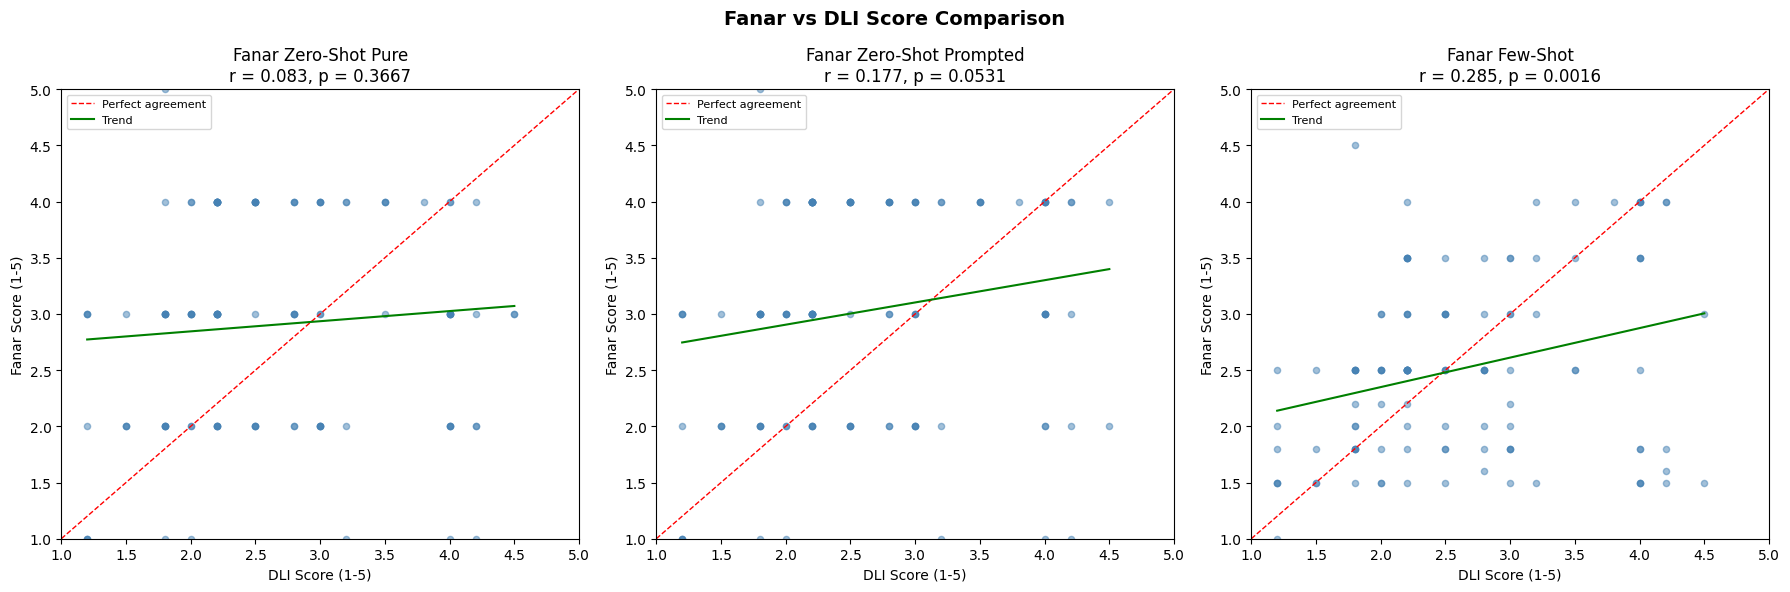

Saved!


In [98]:
# plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

experiments_fanar = [
    ('Fanar Zero-Shot Pure', fanar_zs_pure),
    ('Fanar Zero-Shot Prompted', fanar_zs_prompted),
    ('Fanar Few-Shot', fanar_fs)
]

for ax, (label, df_exp) in zip(axes, experiments_fanar):
    merged = df_exp.merge(
        df_eval[['Statement', 'DLI_1_5_norm']].drop_duplicates(subset='Statement'),
        on='Statement', how='left'
    ).dropna(subset=['LLM_Score', 'DLI_1_5_norm'])

    r, p = stats.pearsonr(merged['LLM_Score'], merged['DLI_1_5_norm'])

    ax.scatter(merged['DLI_1_5_norm'], merged['LLM_Score'],
               alpha=0.5, s=20, color='steelblue')
    ax.plot([1, 5], [1, 5], 'r--', linewidth=1, label='Perfect agreement')

    z = np.polyfit(merged['DLI_1_5_norm'], merged['LLM_Score'], 1)
    p_line = np.poly1d(z)
    x_range = np.linspace(merged['DLI_1_5_norm'].min(), merged['DLI_1_5_norm'].max(), 100)
    ax.plot(x_range, p_line(x_range), 'g-', linewidth=1.5, label='Trend')

    ax.set_xlabel('DLI Score (1-5)')
    ax.set_ylabel('Fanar Score (1-5)')
    ax.set_title(f'{label}\nr = {r:.3f}, p = {p:.4f}')
    ax.set_xlim(1, 5)
    ax.set_ylim(1, 5)
    ax.legend(fontsize=8)

plt.suptitle('Fanar vs DLI Score Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/fanar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

### 4.4 Batches 3 & 4 - Large Validation Set (n=1000)

In [94]:
# Load Batch 3 results and final_1000 sample
zs_clean = pd.read_csv('../results/validation/GPT/Batch_3/results_zeroshot_prompted_final.csv')
fs_clean = pd.read_csv('../results/validation/GPT/Batch_3/results_fewshot_final.csv')

# Load pre-saved final_1000 sample directly
final_1000 = pd.read_csv('../results/validation/final_1000_sample.csv')
print(f"final_1000: {len(final_1000)} sentences")


final_1000: 1000 sentences


In [95]:
# Batch 3 GPT correlation results — reported in Table 9
from scipy import stats

# ZS Prompted
df_zs = final_1000.merge(
    zs_clean[['Statement', 'LLM_Score']],
    left_on='Sentence', right_on='Statement', how='left'
).dropna(subset=['LLM_Score', 'DLI_1_5_norm'])
r_zs, p_zs = stats.pearsonr(df_zs['DLI_1_5_norm'], df_zs['LLM_Score'])
print(f"Batch 3 ZS Prompted GPT — r={r_zs:.3f}, p={p_zs:.4f}, n={len(df_zs)}")

# Few-Shot
df_fs = final_1000.merge(
    fs_clean[['Statement', 'LLM_Score']],
    left_on='Sentence', right_on='Statement', how='left'
).dropna(subset=['LLM_Score', 'DLI_1_5_norm'])
r_fs, p_fs = stats.pearsonr(df_fs['DLI_1_5_norm'], df_fs['LLM_Score'])
print(f"Batch 3 Few-Shot GPT     — r={r_fs:.3f}, p={p_fs:.4f}, n={len(df_fs)}")


Batch 3 ZS Prompted GPT — r=0.212, p=0.0000, n=1000
Batch 3 Few-Shot GPT     — r=0.082, p=0.0099, n=1000


In [96]:
# Define few-shot examples for large-scale experiments
few_shot_examples = get_few_shot_examples(df_full)
print(f"Few-shot examples: {len(few_shot_examples)}")


Few-shot examples: 8


In [ ]:
# sentences_1000_final = final_1000['Sentence'].tolist()

# print("Running Fanar Zero-Shot Prompted on 1000 sentences...")
# fanar_zs_prompted_1000 = await run_experiment_fanar(
#     sentences_1000_final, 
#     lambda s: ZERO_SHOT_PROMPTED.format(sentence=s),
#     model="Fanar", max_concurrent=3, delay=1.5)
# fanar_zs_prompted_1000.to_csv(
#     '../results/validation/Fanar/results_fanar_zeroshot_prompted_1000.csv', 
#     index=False, encoding='utf-8-sig')
# print(f"ZS Prompted done: {len(fanar_zs_prompted_1000)} sentences")

# print("Running Fanar Few-Shot on 1000 sentences...")
# fanar_fs_1000 = await run_experiment_fanar(
#     sentences_1000_final, 
#     lambda s: build_few_shot_prompt(few_shot_examples, s),
#     model="Fanar", max_concurrent=3, delay=1.5)
# fanar_fs_1000.to_csv(
#     '../results/validation/Fanar/results_fanar_fewshot_1000.csv', 
#     index=False, encoding='utf-8-sig')
# print(f"Few-Shot done: {len(fanar_fs_1000)} sentences")

# print("All done!")

Running Fanar Zero-Shot Prompted on 1000 sentences...
ZS Prompted done: 1000 sentences
Running Fanar Few-Shot on 1000 sentences...
Error on sentence 64: Expecting ',' delimiter: line 4 column 131 (char 163)
Error on sentence 64: Expecting ',' delimiter: line 4 column 131 (char 163)
Error on sentence 64: Expecting ',' delimiter: line 4 column 131 (char 163)
Error on sentence 119: Expecting ',' delimiter: line 4 column 144 (char 176)
Error on sentence 119: Expecting ',' delimiter: line 4 column 144 (char 176)
Error on sentence 119: Expecting ',' delimiter: line 4 column 142 (char 174)
Error on sentence 124: Expecting ',' delimiter: line 4 column 126 (char 156)
Error on sentence 124: Expecting ',' delimiter: line 4 column 126 (char 156)
Error on sentence 124: Expecting ',' delimiter: line 4 column 126 (char 156)
Few-Shot done: 1000 sentences
All done!


In [97]:
# Load saved Fanar 1000 results (use instead of rerunning API above)
fanar_zs_prompted_1000 = pd.read_csv('../results/validation/Fanar/results_fanar_zeroshot_prompted_1000.csv')
fanar_fs_1000 = pd.read_csv('../results/validation/Fanar/results_fanar_fewshot_1000.csv')
print(f"Fanar ZS Prompted: {len(fanar_zs_prompted_1000)} sentences")
print(f"Fanar Few-Shot: {len(fanar_fs_1000)} sentences")


Fanar ZS Prompted: 1000 sentences
Fanar Few-Shot: 1000 sentences


In [98]:
# Batch 4 Fanar correlation results — reported in Table 9
from scipy import stats

fanar_zs_1000 = pd.read_csv('../results/validation/Fanar/results_fanar_zeroshot_prompted_1000.csv')
fanar_fs_1000_scores = pd.read_csv('../results/validation/Fanar/results_fanar_fewshot_1000.csv')

df_fanar_zs = final_1000.merge(
    fanar_zs_1000[['Statement', 'LLM_Score']],
    left_on='Sentence', right_on='Statement', how='left'
).dropna(subset=['LLM_Score', 'DLI_1_5_norm'])
r_fzs, p_fzs = stats.pearsonr(df_fanar_zs['DLI_1_5_norm'], df_fanar_zs['LLM_Score'])
print(f"Batch 4 ZS Prompted Fanar — r={r_fzs:.3f}, p={p_fzs:.4f}, n={len(df_fanar_zs)}")

df_fanar_fs = final_1000.merge(
    fanar_fs_1000_scores[['Statement', 'LLM_Score']],
    left_on='Sentence', right_on='Statement', how='left'
).dropna(subset=['LLM_Score', 'DLI_1_5_norm'])
r_ffs, p_ffs = stats.pearsonr(df_fanar_fs['DLI_1_5_norm'], df_fanar_fs['LLM_Score'])
print(f"Batch 4 Few-Shot Fanar   — r={r_ffs:.3f}, p={p_ffs:.4f}, n={len(df_fanar_fs)}")


Batch 4 ZS Prompted Fanar — r=0.168, p=0.0000, n=1000
Batch 4 Few-Shot Fanar   — r=0.178, p=0.0000, n=997


In [228]:
print(f"Fanar ZS Prompted: {len(fanar_zs_prompted_1000)} sentences")
print(f"Fanar Few-Shot: {len(fanar_fs_1000)} sentences")
print(f"Fanar ZS Null scores: {fanar_zs_prompted_1000['LLM_Score'].isna().sum()}")
print(f"Fanar FS Null scores: {fanar_fs_1000['LLM_Score'].isna().sum()}")

Fanar ZS Prompted: 1000 sentences
Fanar Few-Shot: 1000 sentences
Fanar ZS Null scores: 0
Fanar FS Null scores: 3


## 5. Feature Importance Analysis

### 5.1 Run Weighted Experiment (n=500)

> **WARNING:** Running the cell below costs API credits. Use the load cell (5.2) if already run.

In [99]:
# Sample 500 sentences for weighted experiment (125 per quadrant)
# Uses random_state=42 for reproducibility
expanded_sample = (
    df_full.groupby('Quadrant', group_keys=False)[df_full.columns]
    .apply(lambda x: x.sample(min(125, len(x)), random_state=42))
    .reset_index(drop=True)
)
sentences_500 = expanded_sample['Sentence'].tolist()
print(f"Sampled {len(sentences_500)} sentences: {expanded_sample['Quadrant'].value_counts().to_dict()}")


Sampled 500 sentences: {'High BAREC / High DLI': 125, 'High BAREC / Low DLI': 125, 'Low BAREC / High DLI': 125, 'Low BAREC / Low DLI': 125}


In [ ]:
# print("Running weighted experiment on 500 sentences...")
# weighted_results = await run_experiment_weighted(sentences_500)
# weighted_results.to_csv('../results/validation/results_weighted_500_final.csv', 
#                         index=False, encoding='utf-8-sig')
# print(f"Done! {len(weighted_results)} sentences")
# print(weighted_results.head())

Running weighted experiment on 500 sentences...
Progress: 10/500
Progress: 20/500
Progress: 30/500
Progress: 40/500
Progress: 50/500
Progress: 60/500
Progress: 70/500
Progress: 80/500
Progress: 90/500
Progress: 100/500
Progress: 110/500
Progress: 120/500
Progress: 130/500
Progress: 140/500
Progress: 160/500
Progress: 150/500
Progress: 170/500
Progress: 180/500
Progress: 190/500
Progress: 200/500
Progress: 210/500
Progress: 220/500
Progress: 230/500
Progress: 240/500
Progress: 250/500
Progress: 260/500
Progress: 280/500
Progress: 270/500
Progress: 290/500
Progress: 300/500
Progress: 310/500
Progress: 320/500
Progress: 340/500
Progress: 330/500
Progress: 350/500
Progress: 360/500
Progress: 370/500
Progress: 380/500
Progress: 390/500
Progress: 400/500
Error on sentence 415: Error code: 400 - {'error': {'message': "We could not parse the JSON body of your request. (HINT: This likely means you aren't using your HTTP library correctly. The OpenAI API expects a JSON payload, but what was sent

### 5.2 Load Saved Results

In [100]:
weighted_results = pd.read_csv('../results/validation/results_weighted_500_final.csv')
print(f"Loaded: {len(weighted_results)} sentences")

Loaded: 500 sentences


In [28]:
print(f"{len(weighted_results)} sentences")
print(weighted_results[['Overall_Score', 'gpt_diacritics', 'gpt_dotted_letter_proportion','gpt_dot_load_ratio', 
                              'gpt_similar_shapes', 'gpt_chameleon_letters',
                              'gpt_lexical_difficulty', 'gpt_homograph_risk', 
                              'gpt_morphological_complexity']].describe().round(2))

500 sentences
       Overall_Score  gpt_diacritics  gpt_dotted_letter_proportion  \
count         500.00          500.00                        500.00   
mean            2.63            0.99                          2.00   
std             0.86            1.22                          0.74   
min             1.00            0.00                          0.00   
25%             2.00            0.00                          2.00   
50%             3.00            0.00                          2.00   
75%             3.00            2.00                          2.00   
max             4.00            3.00                          3.00   

       gpt_dot_load_ratio  gpt_similar_shapes  gpt_chameleon_letters  \
count              500.00              500.00                 500.00   
mean                 1.68                1.79                   1.90   
std                  0.56                0.60                   0.54   
min                  0.00                0.00                   0.0

### 5.3 GPT vs Formula Feature Correlations

In [101]:
from sklearn.preprocessing import MinMaxScaler
from scipy import stats

# Step 1: convert your continuous features to threshold scores
def features_to_scores(row):
    return {
        'your_diacritics':     3 if row['OVL'] > 0.80 else 2 if row['OVL'] > 0.40 else 1 if row['OVL'] > 0.10 else 0,
        'your_dlp':            2 if row['DLP'] > 0.50 else 1 if row['DLP'] > 0.30 else 0,
        'your_dot_load':       3 if row['Dot_Load_Ratio'] > 1.00 else 2 if row['Dot_Load_Ratio'] > 0.70 else 1 if row['Dot_Load_Ratio'] > 0.50 else 0,
        'your_similar_shapes': 3 if row['Similar_Shape_Density'] > 0.80 else 2 if row['Similar_Shape_Density'] > 0.60 else 1 if row['Similar_Shape_Density'] > 0.40 else 0,
        'your_chameleon':      2 if row['PSC_Density'] > 0.25 else 1 if row['PSC_Density'] > 0.15 else 0,
        'your_rare_words':     3 if row['Lexical_Difficulty'] > 3.50 else 2 if row['Lexical_Difficulty'] > 2.50 else 1 if row['Lexical_Difficulty'] > 1.50 else 0,
        'your_homograph':      2 if row['Homograph_Risk'] > 0.30 else 1 if row['Homograph_Risk'] > 0.10 else 0,
        'your_morph':          4 if row['Avg_Morphological_Complexity'] > 2.50 else 3 if row['Avg_Morphological_Complexity'] > 1.20 else 2 if row['Avg_Morphological_Complexity'] > 0.70 else 1 if row['Avg_Morphological_Complexity'] > 0.40 else 0,
    }

# Step 2: merge GPT results with your features
df_merged = weighted_results.merge(
    df_full[['Sentence', 'OVL', 'DLP', 'Dot_Load_Ratio', 'Similar_Shape_Density',
             'PSC_Density', 'Lexical_Difficulty', 'Homograph_Risk',
             'Avg_Morphological_Complexity', 'DLI_1_5_norm']].drop_duplicates(subset='Sentence'),
    left_on='Statement', right_on='Sentence', how='left'
).dropna()

# Step 3: apply threshold conversion
feature_scores = df_merged.apply(features_to_scores, axis=1, result_type='expand')
df_merged = pd.concat([df_merged.reset_index(drop=True),
                        feature_scores.reset_index(drop=True)], axis=1)

# Step 4: normalize both to 0-1
gpt_cols = ['gpt_diacritics', 'gpt_dotted_letter_proportion', 'gpt_dot_load_ratio',
            'gpt_similar_shapes', 'gpt_chameleon_letters', 'gpt_lexical_difficulty',
            'gpt_homograph_risk', 'gpt_morphological_complexity']

your_cols = ['your_diacritics', 'your_dlp', 'your_dot_load', 'your_similar_shapes',
             'your_chameleon', 'your_rare_words', 'your_homograph', 'your_morph']

scaler_gpt = MinMaxScaler()
scaler_your = MinMaxScaler()

df_merged[gpt_cols] = scaler_gpt.fit_transform(df_merged[gpt_cols].fillna(0))
df_merged[your_cols] = scaler_your.fit_transform(df_merged[your_cols].fillna(0))

# Step 5: correlate
feature_pairs = [
    ('gpt_diacritics',                'your_diacritics',    'OVL vs Diacritics'),
    ('gpt_dotted_letter_proportion',  'your_dlp',           'DLP vs Dotted Letter Proportion'),
    ('gpt_dot_load_ratio',            'your_dot_load',      'DLR vs Dot Load Ratio'),
    ('gpt_similar_shapes',            'your_similar_shapes','Similar_Shape_Density'),
    ('gpt_chameleon_letters',         'your_chameleon',     'PSC_Density'),
    ('gpt_lexical_difficulty',        'your_rare_words',    'Lexical_Difficulty'),
    ('gpt_homograph_risk',            'your_homograph',     'Homograph_Risk'),
    ('gpt_morphological_complexity',  'your_morph',         'Morph_Complexity'),
]

print("=== GPT vs Your Feature Scores (normalized 0-1) ===")
for gpt_feat, your_feat, label in feature_pairs:
    r, p = stats.pearsonr(df_merged[gpt_feat], df_merged[your_feat])
    sig = "✓" if p < 0.05 else "✗"
    print(f"{label:35s}  r={r:.3f}  p={p:.4f}  {sig}")

# Step 6: overall score correlation
r, p = stats.pearsonr(df_merged['Overall_Score'], df_merged['DLI_1_5_norm'])
print(f"\nGPT Overall Score vs DLI_1_5_norm: r={r:.3f}, p={p:.4f}")

print(f"\nMerged dataset: {len(df_merged)} sentences")

=== GPT vs Your Feature Scores (normalized 0-1) ===
OVL vs Diacritics                    r=0.887  p=0.0000  ✓
DLP vs Dotted Letter Proportion      r=0.464  p=0.0000  ✓
DLR vs Dot Load Ratio                r=0.283  p=0.0000  ✓
Similar_Shape_Density                r=0.148  p=0.0009  ✓
PSC_Density                          r=0.336  p=0.0000  ✓
Lexical_Difficulty                   r=0.326  p=0.0000  ✓
Homograph_Risk                       r=0.384  p=0.0000  ✓
Morph_Complexity                     r=0.282  p=0.0000  ✓

GPT Overall Score vs DLI_1_5_norm: r=0.246, p=0.0000

Merged dataset: 499 sentences


### 5.4 RF & DT Feature Importance (Table 11)

In [27]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score

# features for training
gpt_feature_cols = ['gpt_diacritics', 'gpt_dotted_letter_proportion', 'gpt_dot_load_ratio',
                    'gpt_similar_shapes', 'gpt_chameleon_letters', 'gpt_lexical_difficulty',
                    'gpt_homograph_risk', 'gpt_morphological_complexity']

X = df_merged[gpt_feature_cols].fillna(0).values
y = df_merged['Overall_Score'].fillna(df_merged['Overall_Score'].mean()).values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_r2 = r2_score(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r, rf_p = stats.pearsonr(y_test, rf_pred)

print(f"=== Random Forest ===")
print(f"R²:  {rf_r2:.4f}")
print(f"MAE: {rf_mae:.4f}")
print(f"r:   {rf_r:.4f}, p={rf_p:.4f}")
print(f"\nFeature Importances:")
for feat, imp in sorted(zip(gpt_feature_cols, rf.feature_importances_), 
                         key=lambda x: x[1], reverse=True):
    print(f"  {feat:35s} {imp:.4f}")

# Decision Tree
dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_r2 = r2_score(y_test, dt_pred)
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_r, dt_p = stats.pearsonr(y_test, dt_pred)

print(f"\n=== Decision Tree ===")
print(f"R²:  {dt_r2:.4f}")
print(f"MAE: {dt_mae:.4f}")
print(f"r:   {dt_r:.4f}, p={dt_p:.4f}")
print(f"\nFeature Importances:")
for feat, imp in sorted(zip(gpt_feature_cols, dt.feature_importances_), 
                         key=lambda x: x[1], reverse=True):
    print(f"  {feat:35s} {imp:.4f}")

=== Random Forest ===
R²:  0.6582
MAE: 0.3743
r:   0.8114, p=0.0000

Feature Importances:
  gpt_dotted_letter_proportion        0.3438
  gpt_morphological_complexity        0.1764
  gpt_lexical_difficulty              0.1429
  gpt_diacritics                      0.1270
  gpt_chameleon_letters               0.0662
  gpt_similar_shapes                  0.0624
  gpt_homograph_risk                  0.0426
  gpt_dot_load_ratio                  0.0388

=== Decision Tree ===
R²:  0.5913
MAE: 0.4416
r:   0.7703, p=0.0000

Feature Importances:
  gpt_dotted_letter_proportion        0.4690
  gpt_morphological_complexity        0.2065
  gpt_lexical_difficulty              0.1660
  gpt_diacritics                      0.1395
  gpt_similar_shapes                  0.0190
  gpt_dot_load_ratio                  0.0000
  gpt_chameleon_letters               0.0000
  gpt_homograph_risk                  0.0000


### 5.5 Feature Importance Figure (Figure 7)

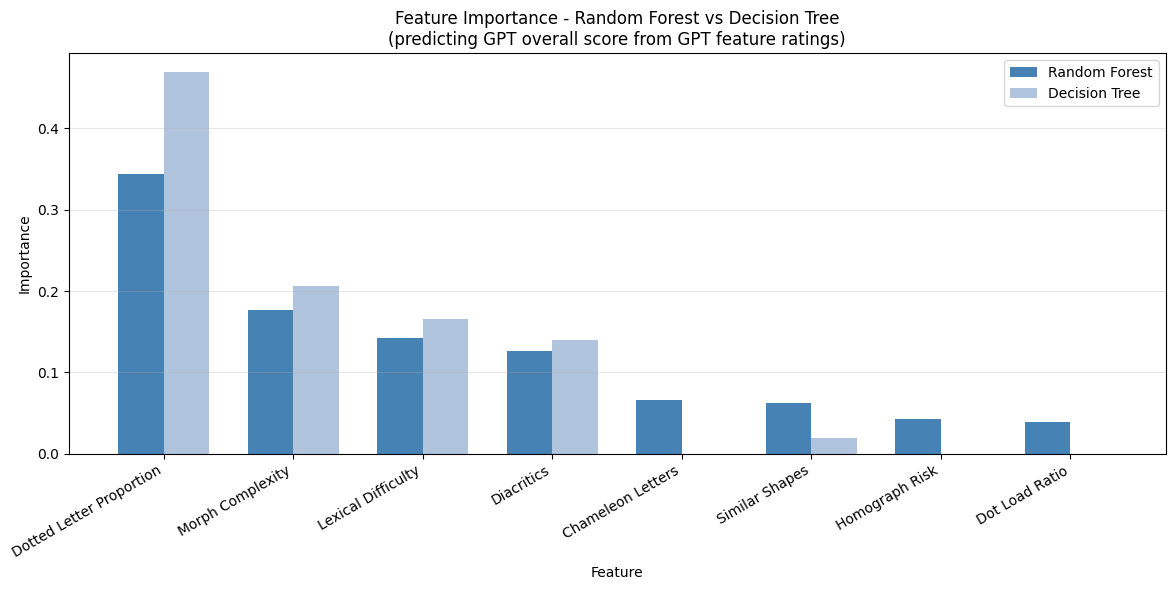

Saved!


In [32]:
import matplotlib.pyplot as plt
import numpy as np

# feature importance data
features = ['Dotted Letter Proportion', 'Morph Complexity', 'Lexical Difficulty',
            'Diacritics', 'Chameleon Letters', 'Similar Shapes', 
            'Homograph Risk', 'Dot Load Ratio']

rf_importances = [0.3438, 0.1764, 0.1429, 0.1270, 0.0662, 0.0624, 0.0426, 0.0388]
dt_importances = [0.4690, 0.2065, 0.1660, 0.1395, 0.0000, 0.0190, 0.0000, 0.0000]

x = np.arange(len(features))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, rf_importances, width, label='Random Forest', color='steelblue')
bars2 = ax.bar(x + width/2, dt_importances, width, label='Decision Tree', color='lightsteelblue')

ax.set_xlabel('Feature')
ax.set_ylabel('Importance')
ax.set_title('Feature Importance - Random Forest vs Decision Tree\n(predicting GPT overall score from GPT feature ratings)')
ax.set_xticks(x)
ax.set_xticklabels(features, rotation=30, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/feature_importance_rf_dt_NEW_no_value_labels.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

## 6. Weighted DLI

Computes DLI_weighted using RF-derived feature importance weights (Section 4.6).

In [23]:
# apply to full dataset
df_full['DLI_weighted'] = df_full.apply(calculate_DLI_weighted, axis=1)

# normalize to 1-5
observed_max_w = df_full['DLI_weighted'].max()
df_full['DLI_weighted_1_5'] = df_full['DLI_weighted'].apply(
    lambda x: round(1 + (x / observed_max_w) * 4, 2)
)

print(df_full[['DLI', 'DLI_weighted', 'DLI_weighted_1_5']].describe().round(3))

             DLI  DLI_weighted  DLI_weighted_1_5
count  69441.000     69441.000         69441.000
mean       6.179         0.773             2.480
std        1.777         0.264             0.506
min        0.000         0.000             1.000
25%        5.000         0.620             2.190
50%        6.000         0.800             2.530
75%        7.000         0.930             2.780
max       16.000         2.090             5.000


In [31]:
# Note: requires df_merged from Section 5 to be defined first
# proper merge
df_comparison = df_merged[['Statement', 'Overall_Score']].merge(
    df_full[['Sentence', 'DLI_1_5_norm', 'DLI_weighted_1_5']].drop_duplicates(subset='Sentence'),
    left_on='Statement', right_on='Sentence',
    how='inner'
)

print(f"Matched: {len(df_comparison)}")

r_old, p_old = stats.pearsonr(df_comparison['Overall_Score'], df_comparison['DLI_1_5_norm'])
r_new, p_new = stats.pearsonr(df_comparison['Overall_Score'], df_comparison['DLI_weighted_1_5'])

print(f"Old DLI vs GPT: r={r_old:.4f}, p={p_old:.4f}")
print(f"New weighted DLI vs GPT: r={r_new:.4f}, p={p_new:.4f}")

Matched: 499
Old DLI vs GPT: r=0.2465, p=0.0000
New weighted DLI vs GPT: r=0.2539, p=0.0000


## 7. Additional Factors Analysis

Categorizes qualitative GPT additional factor descriptions (Section 4.5.1).

In [41]:
# Filter non-none responses
non_none = weighted_results[
    ~weighted_results['Additional_Factors'].str.lower().str.strip().isin(['none', 'n/a', ''])
].copy()
print(f"Non-none responses: {len(non_none)} / {len(weighted_results)}")

Non-none responses: 500 / 500


### 7.1 Categorize with GPT

> **WARNING:** API credits needed. Load from saved CSV if already run.

In [51]:
# Categorize with GPT

CATEGORIZE_PROMPT = """You are analyzing qualitative descriptions of additional factors 
that affect Arabic text decoding difficulty for dyslexic readers, as identified by an 
expert rater. Assign the following description to one or more of these categories:

- diacritization - mentions tashkeel, shadda, tanwin, sukun, vocalization, visual clutter from vowel marks
- punctuation - mentions commas, colons, question marks, ellipsis, visual distraction from punctuation
- clitic_segmentation - mentions clitics, suffixes, prefixes, segmentation demands, affix attachment
- cursive_connectivity - mentions cursive, ligatures, letter crowding, connectivity, joined script
- sentence_length - mentions short/long sentence, working memory load, word count
- special_characters - mentions hamza, ta marbuta, alif variants, proper nouns, bullet points
- dual_role - mentions a feature that simultaneously helps AND hinders decoding (e.g. tashkeel reduces ambiguity but adds visual clutter)

Description: {text}

Respond in JSON only with no extra text:
{{"categories": ["diacritization", "punctuation"]}}"""

In [52]:

async def categorize_single(i, text, results, semaphore, client):
    async with semaphore:
        try:
            prompt = CATEGORIZE_PROMPT.format(text=text)
            response = await client.chat.completions.create(
                model="gpt-5-mini",
                messages=[{"role": "user", "content": prompt}]
            )
            content = response.choices[0].message.content.strip()
            content = content.replace("```json", "").replace("```", "").strip()
            parsed = json.loads(content)
            results[i] = parsed.get('categories', ['other'])
        except Exception as e:
            print(f"Error on row {i}: {e}")
            results[i] = ['other']
        
        if (i + 1) % 20 == 0:
            print(f"Progress: {i+1}/{len(non_none)}", flush=True)
        
        await asyncio.sleep(0.05)


async def categorize_all(texts):
    client = get_async_client()
    semaphore = asyncio.Semaphore(20)
    results = [None] * len(texts)
    tasks = [categorize_single(i, t, results, semaphore, client) 
             for i, t in enumerate(texts)]
    await asyncio.gather(*tasks)
    return results

In [ ]:
# # run categorization
# texts = non_none['Additional_Factors'].tolist()
# categories = await categorize_all(texts)
# non_none['AF_categories'] = categories
# print("Done!")

Progress: 20/500
Progress: 40/500
Progress: 60/500
Progress: 100/500
Progress: 80/500
Progress: 120/500
Progress: 140/500
Progress: 160/500
Progress: 180/500
Progress: 200/500
Progress: 220/500
Progress: 240/500
Progress: 260/500
Progress: 280/500
Progress: 300/500
Progress: 320/500
Progress: 340/500
Progress: 360/500
Progress: 380/500
Progress: 400/500
Progress: 420/500
Progress: 440/500
Progress: 460/500
Progress: 480/500
Progress: 500/500
Done!


### 7.2 Frequency Analysis & Visualization

In [102]:
# Load saved categorization results if not already in memory
# Run this if you skipped the API categorization cell above
try:
    # check if AF_categories already exists as lists
    test = non_none['AF_categories'].iloc[0]
    if isinstance(test, str):
        raise ValueError("AF_categories is string, need to parse")
    print("AF_categories already loaded as lists")
except:
    weighted_results_saved = pd.read_csv('../results/validation/results_weighted_500_final.csv')
    non_none = weighted_results_saved[
        weighted_results_saved['AF_categories'].notna() &
        (weighted_results_saved['AF_categories'].str.strip() != '')
    ].copy()
    non_none['AF_categories'] = non_none['AF_categories'].apply(lambda x: x.split('|') if isinstance(x, str) else x)
    print(f"Loaded and parsed {len(non_none)} categorized sentences")


Loaded and parsed 499 categorized sentences


In [55]:
# Frequency Analysis
from collections import Counter

# explode categories and count
all_cats = [cat for sublist in non_none['AF_categories'] for cat in sublist]
cat_counts = Counter(all_cats)
cat_df = pd.DataFrame(cat_counts.items(), columns=['Category', 'Count']).sort_values('Count', ascending=False)
print(cat_df)
print(f"\nTotal sentences with additional factors: {len(non_none)} ({len(non_none)/len(weighted_results)*100:.1f}%)")

               Category  Count
0        diacritization    352
1           punctuation    310
4       sentence_length    248
6    special_characters    237
5   clitic_segmentation    203
3             dual_role     85
2  cursive_connectivity     49

Total sentences with additional factors: 500 (100.0%)


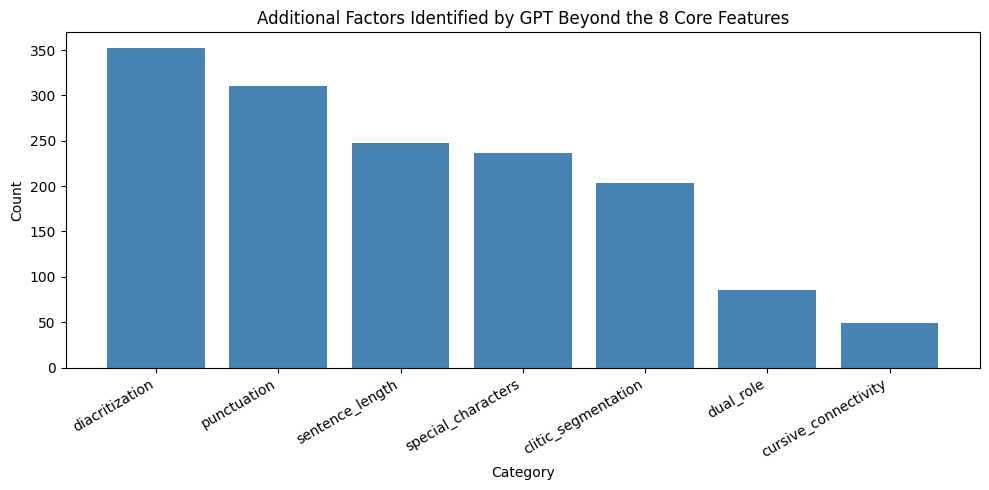

In [56]:
# Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(cat_df['Category'], cat_df['Count'], color='steelblue')
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Additional Factors Identified by GPT Beyond the 8 Core Features')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../results/figures/additional_factors.png', dpi=150, bbox_inches='tight')
plt.show()

In [57]:
# Summary stats for thesis paragraph
print("\n=== Summary for thesis ===")
print(f"Sentences with additional factors: {len(non_none)} ({len(non_none)/len(weighted_results)*100:.1f}%)")
print(f"Most common categories:")
for cat, count in cat_counts.most_common(3):
    print(f"  {cat}: {count} ({count/len(non_none)*100:.1f}% of non-none responses)")


=== Summary for thesis ===
Sentences with additional factors: 500 (100.0%)
Most common categories:
  diacritization: 352 (70.4% of non-none responses)
  punctuation: 310 (62.0% of non-none responses)
  sentence_length: 248 (49.6% of non-none responses)


In [ ]:
# COMMENTED OUT — file already saved with AF_categories
# Uncomment only if you reran categorization above
# Save to CSV
# weighted_results_with_cats = weighted_results.copy()
# weighted_results_with_cats.loc[non_none.index, 'AF_categories'] = (
#     non_none['AF_categories'].apply(lambda x: '|'.join(x))
# )
# weighted_results_with_cats.to_csv('../results/validation/results_weighted_500_final.csv', 
#                                    index=False, encoding='utf-8-sig')
# print("Saved!")
# print(weighted_results_with_cats['AF_categories'].head(5))

Saved!
0    diacritization|punctuation|cursive_connectivit...
1                           diacritization|punctuation
2                           diacritization|punctuation
3      sentence_length|clitic_segmentation|punctuation
4    diacritization|clitic_segmentation|punctuation...
Name: AF_categories, dtype: object


## 8. SVR Model

Trains SVR models on LLM silver labels and applies to full corpus (Table 10).

In [103]:
# load LLM scores and merge with features
llm_scores = pd.read_csv('../results/validation/GPT/Batch_2/results_zeroshot_prompted_v2.csv')
df_features = df_eval.merge(
    llm_scores[['Statement', 'LLM_Score']],
    on='Statement', how='left'
).merge(
    df_full[['Sentence'] + FEATURE_COLS].drop_duplicates(subset='Sentence'),
    left_on='Statement', right_on='Sentence', how='left'
).dropna(subset=FEATURE_COLS + ['LLM_Score'])

print(f"Training data: {len(df_features)} sentences")

# train
model, scaler, results = train_svr(df_features)

Training data: 120 sentences

=== SVR Results ===
Train/Test: 96/24
MAE:        0.5626
R²:         0.5118
Pearson r:  0.7474  (p=0.0000)
CV MAE:     0.6567 ± 0.0619


In [104]:
# load pilot few-shot ratings
fs_pilot_scores = pd.read_csv('../results/validation/GPT/Batch_2/results_fewshot_v2.csv')

df_features_fs_pilot = df_eval.merge(
    fs_pilot_scores[['Statement', 'LLM_Score']],
    on='Statement', how='left'
).merge(
    df_full[['Sentence'] + FEATURE_COLS].drop_duplicates(subset='Sentence'),
    left_on='Statement', right_on='Sentence', how='left'
).dropna(subset=FEATURE_COLS + ['LLM_Score'])

print(f"Training data: {len(df_features_fs_pilot)} sentences")

model_fs_pilot, scaler_fs_pilot, results_fs_pilot = train_svr(df_features_fs_pilot)

Training data: 120 sentences

=== SVR Results ===
Train/Test: 96/24
MAE:        0.5002
R²:         0.3987
Pearson r:  0.6763  (p=0.0003)
CV MAE:     0.5275 ± 0.0331


In [105]:
# reload clean data
zs_clean = pd.read_csv('../results/validation/GPT/Batch_3/results_zeroshot_prompted_final.csv')
fs_clean = pd.read_csv('../results/validation/GPT/Batch_3/results_fewshot_final.csv')

# merge with features
df_zs_clean = final_1000.merge(
    zs_clean[['Statement', 'LLM_Score']],
    left_on='Sentence', right_on='Statement', how='left'
).dropna(subset=FEATURE_COLS + ['LLM_Score'])

df_fs_clean = final_1000.merge(
    fs_clean[['Statement', 'LLM_Score']],
    left_on='Sentence', right_on='Statement', how='left'
).dropna(subset=FEATURE_COLS + ['LLM_Score'])

print(f"ZS clean: {len(df_zs_clean)}")
print(f"FS clean: {len(df_fs_clean)}")

# train SVR on each
model_zs_clean, scaler_zs_clean, results_zs_clean = train_svr(df_zs_clean)
model_fs_clean, scaler_fs_clean, results_fs_clean = train_svr(df_fs_clean)

ZS clean: 1000
FS clean: 1000

=== SVR Results ===
Train/Test: 800/200
MAE:        0.7347
R²:         0.1467
Pearson r:  0.4278  (p=0.0000)
CV MAE:     0.6942 ± 0.0065

=== SVR Results ===
Train/Test: 800/200
MAE:        0.5545
R²:         0.2261
Pearson r:  0.5091  (p=0.0000)
CV MAE:     0.5772 ± 0.0464


In [106]:
# Save trained SVR models
# Best model: large set ZS Prompted (r=0.509, reported in Table 10)
import os
os.makedirs('../results/models/', exist_ok=True)
save_model(model_zs_clean, scaler_zs_clean, '../results/models/svr_best.joblib')
save_model(model, scaler, '../results/models/svr_pilot_zs_prompted.joblib')
save_model(model_fs_clean, scaler_fs_clean, '../results/models/svr_large_fewshot.joblib')
print("Models saved!")


Model saved to ../results/models/svr_best.joblib
Model saved to ../results/models/svr_pilot_zs_prompted.joblib
Model saved to ../results/models/svr_large_fewshot.joblib
Models saved!


In [ ]:
# Load saved models (run this instead of retraining if models already saved)
# model_zs_clean, scaler_zs_clean = load_model('../results/models/svr_best.joblib')
# model, scaler = load_model('../results/models/svr_pilot_zs_prompted.joblib')
# model_fs_clean, scaler_fs_clean = load_model('../results/models/svr_large_fewshot.joblib')
# print("Models loaded!")


In [ ]:
# Apply best SVR model to full corpus (large set ZS Prompted, r=0.509)
# Optional — adds SVR_Score column to df_full for inspection
# Not required for figures or other downstream cells
df_full['SVR_Score'] = predict_svr(model_zs_clean, scaler_zs_clean, df_full)
print(df_full['SVR_Score'].describe().round(3))

count    69441.000000
mean         2.949160
std          0.502111
min          1.018768
25%          2.648980
50%          2.971232
75%          3.220541
max          4.392982
Name: SVR_Score, dtype: float64
SVR vs DLI_1_5_norm: r=0.5119, p=0.0000


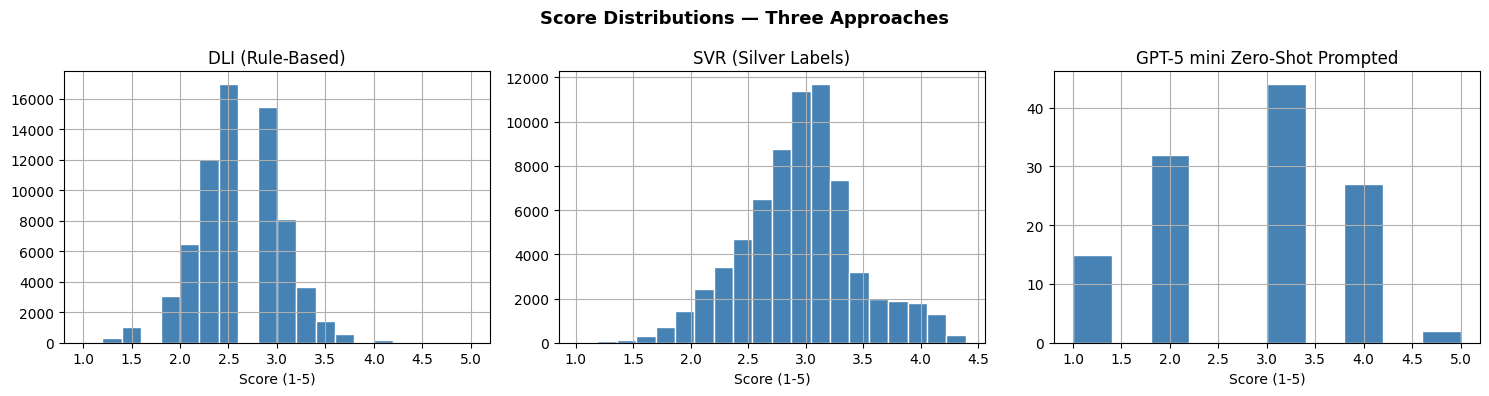

In [103]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df_full['DLI_1_5_norm'].hist(bins=20, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('DLI (Rule-Based)')
axes[0].set_xlabel('Score (1-5)')

df_full['SVR_Score'].hist(bins=20, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('SVR (Silver Labels)')
axes[1].set_xlabel('Score (1-5)')

# LLM scores only on 120 sentences
zs_prompted_v2['LLM_Score'].hist(bins=10, ax=axes[2], color='steelblue', edgecolor='white')
axes[2].set_title('GPT-5 mini Zero-Shot Prompted')
axes[2].set_xlabel('Score (1-5)')

plt.suptitle('Score Distributions — Three Approaches', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [146]:
# give it any sentence, get a DLI score
def predict_dli(sentence):
    # compute features
    features = {
        'DLP': dotted_letter_proportion(sentence),
        'Dot_Load_Ratio': dot_load_ratio(sentence),
        'OVL': ovl(sentence),
        'Similar_Shape_Density': similar_shape_density(sentence),
        'PSC_Density': psc_chameleon_prop(sentence),
        'Lexical_Difficulty': lexical_difficulty_density(sentence, samer_lookup, samer_lookup_pos),
        'Homograph_Risk': homograph_risk_density(sentence, samer_surface_homographs),
        'Avg_Morphological_Complexity': avg_morphological_complexity(sentence)
    }
    
    df = pd.DataFrame([features])
    score = predict_svr(model, scaler, df)
    return round(score[0], 2)

# test
print(predict_dli("الكتاب على الطاولة"))
print(predict_dli("فَإِنْ كَذَبَنِي فَكَذِّبُوهُ"))

1.75
2.5


In [ ]:
def score_sentence(sentence):
    """
    Score an Arabic sentence using all three DLI approaches.
    Returns rule-based DLI, weighted DLI, and SVR predicted score.
    """
    # compute features
    row = pd.Series({
        'DLP':                          dotted_letter_proportion(sentence),
        'Dot_Load_Ratio':               dot_load_ratio(sentence),
        'OVL':                          ovl(sentence),
        'Similar_Shape_Density':        similar_shape_density(sentence),
        'PSC_Density':                  psc_chameleon_prop(sentence),
        'Lexical_Difficulty':           lexical_difficulty_density(sentence, samer_lookup, samer_lookup_pos),
        'Homograph_Risk':               homograph_risk_density(sentence, samer_surface_homographs),
        'Avg_Morphological_Complexity': avg_morphological_complexity(sentence)
    })

    # rule-based DLI (1-5 norm)
    raw_dli = calculate_DLI(row)
    dli_1_5 = round(1 + (raw_dli / 22) * 4, 2)

    # weighted DLI (1-5 norm)
    raw_weighted = calculate_DLI_weighted(row)
    observed_max_w = df_full['DLI_weighted'].max()
    dli_weighted_1_5 = round(1 + (raw_weighted / observed_max_w) * 4, 2)

    # SVR prediction
    svr_score = round(predict_svr(model, scaler, pd.DataFrame([row]))[0], 2)

    print(f"Sentence:      {sentence[:60]}")
    print(f"Raw DLI:       {raw_dli:.3f}")
    print(f"DLI (equal):   {dli_1_5}")
    print(f"DLI (weighted):{dli_weighted_1_5}")
    print(f"SVR score:     {svr_score}")
    print()

    return dli_1_5, dli_weighted_1_5, svr_score

# test on a few sentences
score_sentence("الكتاب على الطاولة")
score_sentence("فَإِنْ كَذَبَنِي فَكَذِّبُوهُ")
score_sentence("وسيكتبونها فيها وبها")
score_sentence("بِسْبِسَةُ صَرَخَتْ تُصَحِّي دِعْبِسَةَ وَنَرْجِسَةَ")

Sentence:      الكتاب على الطاولة
Raw DLI:       2.000
DLI (equal):   1.36
DLI (weighted):2.05
SVR score:     1.75

Sentence:      فَإِنْ كَذَبَنِي فَكَذِّبُوهُ
Raw DLI:       14.000
DLI (equal):   3.55
DLI (weighted):4.15
SVR score:     2.5

Sentence:      وسيكتبونها فيها وبها
Raw DLI:       8.000
DLI (equal):   2.45
DLI (weighted):3.35
SVR score:     2.43

Sentence:      بِسْبِسَةُ صَرَخَتْ تُصَحِّي دِعْبِسَةَ وَنَرْجِسَةَ
Raw DLI:       13.000
DLI (equal):   3.36
DLI (weighted):3.75
SVR score:     3.03



(3.36, 3.75, 3.03)

## 9. Figures

Generates all thesis figures. Run after Sections 2 and 3.

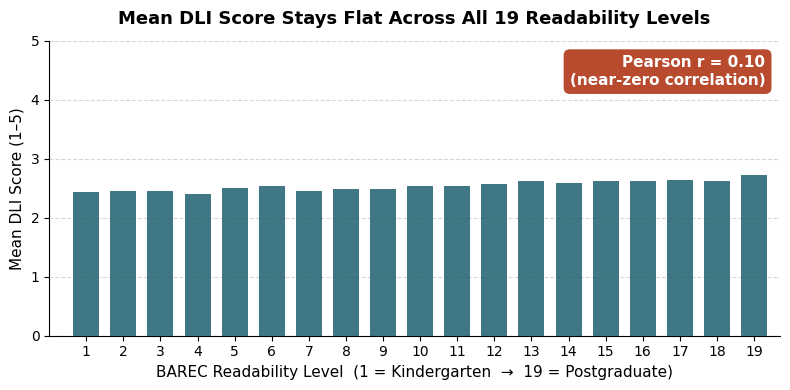

In [171]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

mean_dli = df_full.groupby('Readability_Level_19')['DLI_1_5_norm'].mean()

levels = mean_dli.index.tolist()
values = mean_dli.values.tolist()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#1E5F6E'] * len(levels)
ax.bar(levels, values, color=colors, width=0.7, alpha=0.85, zorder=3)

ax.set_ylim(0, 5)
ax.set_xlim(0, 19.7)
ax.set_xticks(levels)
ax.set_xticklabels([str(l) for l in levels], fontsize=10)
ax.set_xlabel('BAREC Readability Level  (1 = Kindergarten  →  19 = Postgraduate)', fontsize=11)
ax.set_ylabel('Mean DLI Score (1–5)', fontsize=11)
ax.set_title('Mean DLI Score Stays Flat Across All 19 Readability Levels', 
             fontsize=13, fontweight='bold', pad=12)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.annotate('Pearson r = 0.10\n(near-zero correlation)',
            xy=(0.98, 0.95), xycoords='axes fraction',
            ha='right', va='top', fontsize=11, fontweight='bold',
            color='white',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#B84A2E', edgecolor='none'))

early = mpatches.Patch(color='#B84A2E', alpha=0.85, label='Early grades (KG–6)')
later = mpatches.Patch(color='#1E5F6E', alpha=0.85, label='Later levels (7–Postgrad)')

plt.tight_layout()
plt.savefig('../results/figures/fig1_dli_flat.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

In [233]:
from scipy import stats
rho, p = stats.spearmanr(df_full['Readability_Level_19'], df_full['DLI_1_5_norm'])
print(f"Spearman rho = {rho:.3f}, p = {p:.4f}")

Spearman rho = 0.112, p = 0.0000


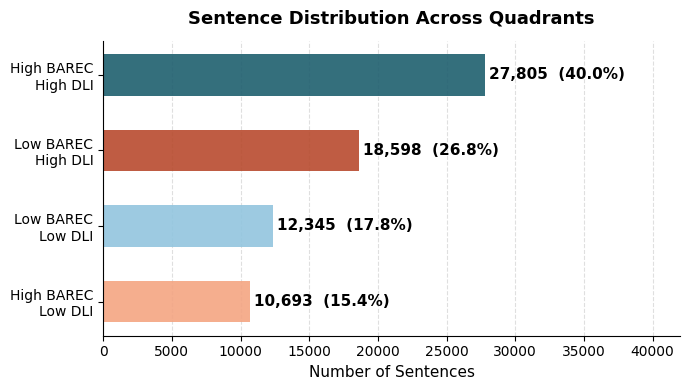

In [ ]:
import matplotlib.pyplot as plt

labels = ['High BAREC\nLow DLI', 'Low BAREC\nLow DLI', 'Low BAREC\nHigh DLI', 'High BAREC\nHigh DLI']
counts = [10693, 12345, 18598, 27805]
pcts = [15.4, 17.8, 26.8, 40.0]
colors = ['#F4A582', '#92C5DE', '#B84A2E', '#1E5F6E']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(labels, counts, color=colors, alpha=0.9, height=0.55)

for bar, pct, count in zip(bars, pcts, counts):
    ax.text(bar.get_width() + 300, bar.get_y() + bar.get_height()/2,
            f'{count:,}  ({pct}%)', va='center', fontsize=11, fontweight='600')

ax.set_xlabel('Number of Sentences', fontsize=11)
ax.set_xlim(0, 42000)  # wider so labels don't crowd
ax.set_title('Sentence Distribution Across Quadrants', fontsize=13, fontweight='bold', pad=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)


plt.tight_layout()
plt.savefig('../results/figures/fig3_quadrant_bar1.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

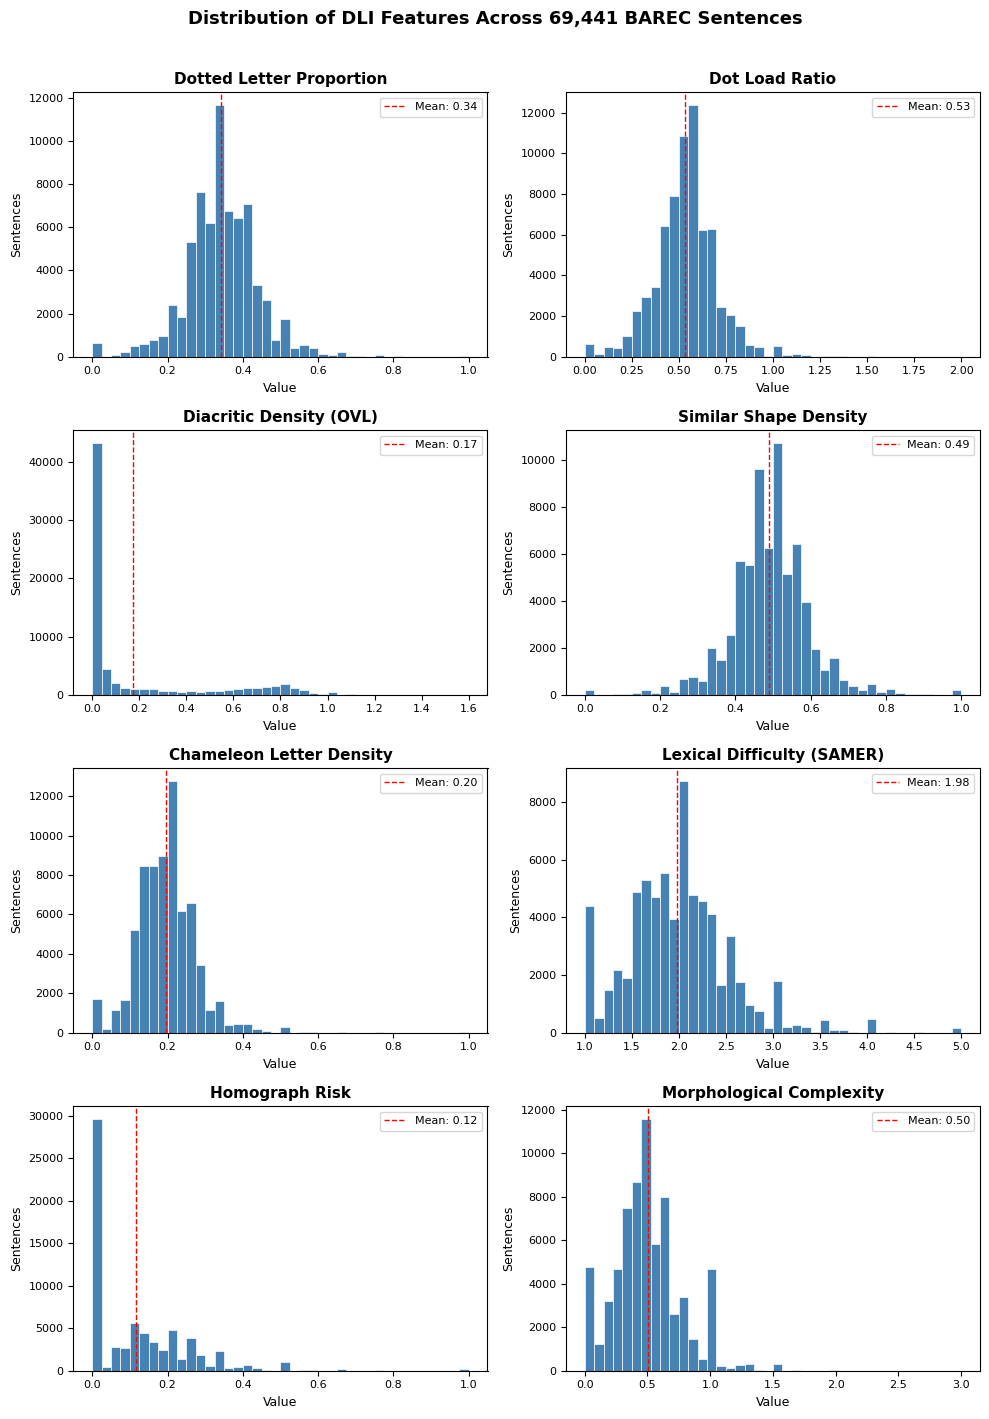

Saved!


In [191]:
import matplotlib.pyplot as plt

feature_labels = {
    'DLP': 'Dotted Letter Proportion',
    'Dot_Load_Ratio': 'Dot Load Ratio',
    'OVL': 'Diacritic Density (OVL)',
    'Similar_Shape_Density': 'Similar Shape Density',
    'PSC_Density': 'Chameleon Letter Density',
    'Lexical_Difficulty': 'Lexical Difficulty (SAMER)',
    'Homograph_Risk': 'Homograph Risk',
    'Avg_Morphological_Complexity': 'Morphological Complexity'
}

fig, axes = plt.subplots(4, 2, figsize=(10, 14))
axes = axes.flatten()

for i, (col, label) in enumerate(feature_labels.items()):
    axes[i].hist(df_full[col], bins=40, color='steelblue', 
                 edgecolor='white', linewidth=0.5)
    axes[i].set_title(label, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value', fontsize=9)
    axes[i].set_ylabel('Sentences', fontsize=9)
    axes[i].tick_params(labelsize=8)
    
    # add vertical line at corpus mean
    mean_val = df_full[col].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', 
                    linewidth=1, label=f'Mean: {mean_val:.2f}')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribution of DLI Features Across 69,441 BAREC Sentences', 
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
# plt.savefig('../results/figures/feature_distributions.png', 
            # dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

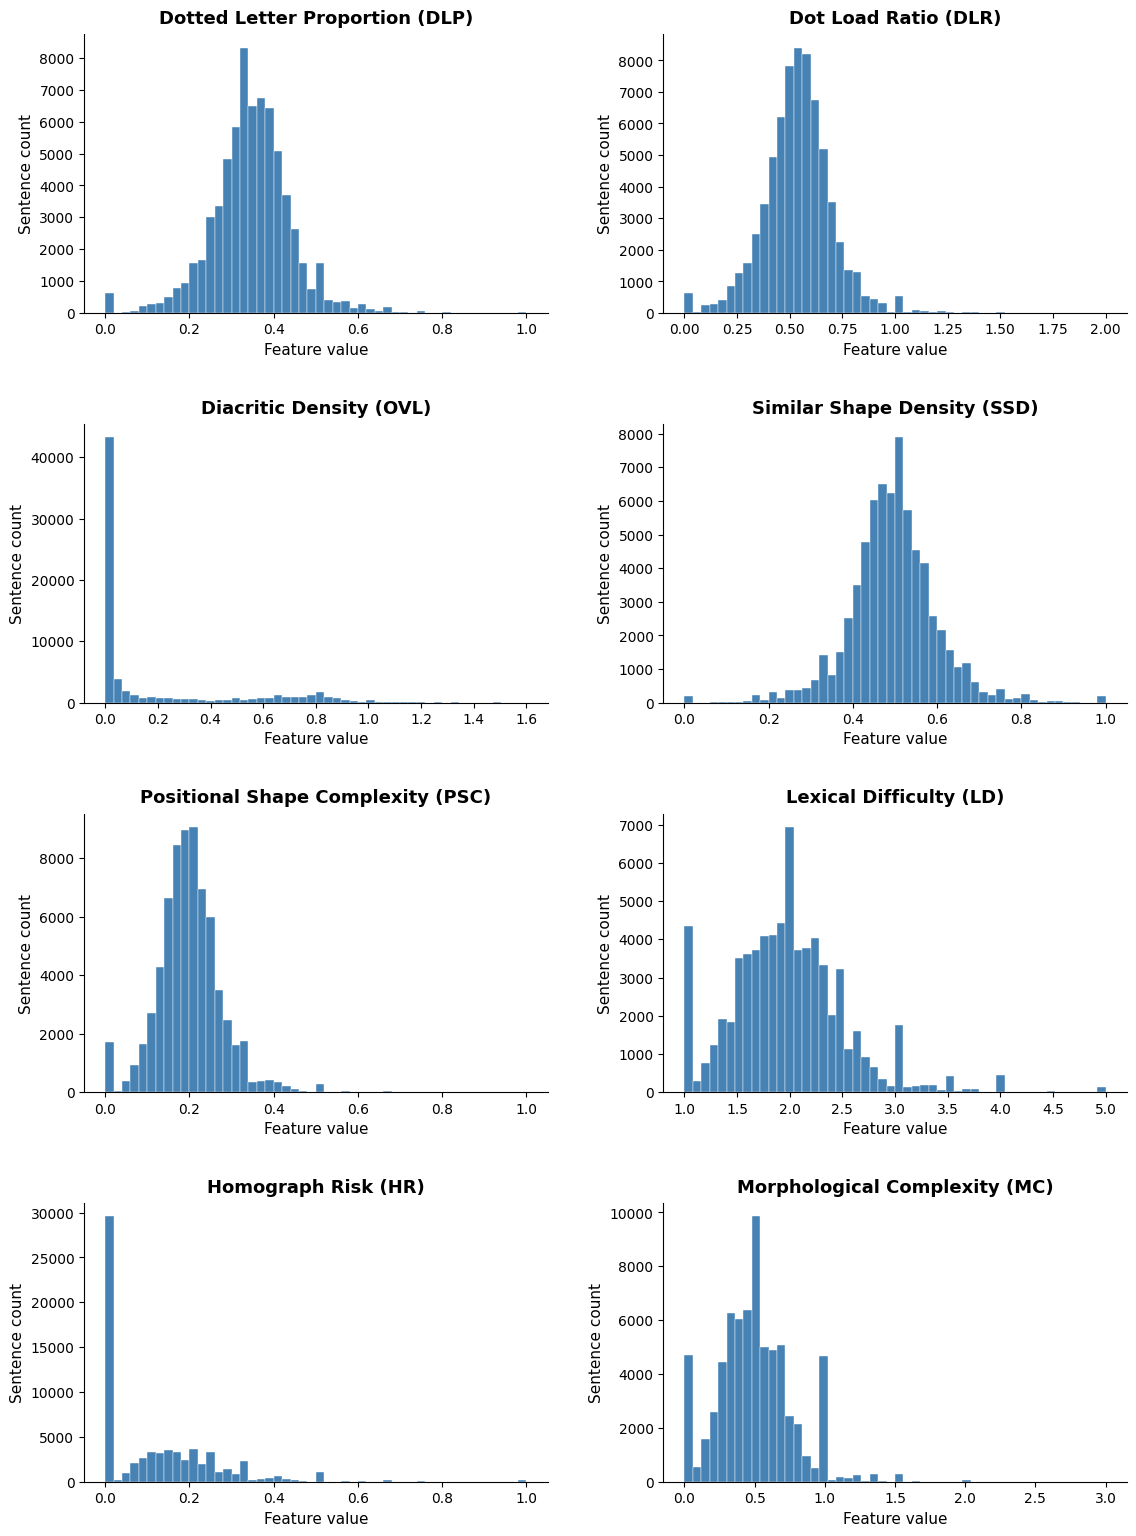

In [197]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

features = ['DLP', 'Dot_Load_Ratio', 'OVL', 'Similar_Shape_Density',
            'PSC_Density', 'Lexical_Difficulty', 'Homograph_Risk', 
            'Avg_Morphological_Complexity']

labels = ['Dotted Letter Proportion (DLP)', 'Dot Load Ratio (DLR)',
          'Diacritic Density (OVL)', 'Similar Shape Density (SSD)',
          'Positional Shape Complexity (PSC)', 'Lexical Difficulty (LD)',
          'Homograph Risk (HR)', 'Morphological Complexity (MC)']

fig, axes = plt.subplots(4, 2, figsize=(12, 16))
axes = axes.flatten()

for i, (feat, label) in enumerate(zip(features, labels)):
    axes[i].hist(df_full[feat].dropna(), bins=50, color='steelblue', 
                 edgecolor='white', linewidth=0.3)
    axes[i].set_title(label, fontsize=13, fontweight='bold', pad=8)
    axes[i].set_xlabel('Feature value', fontsize=11)
    axes[i].set_ylabel('Sentence count', fontsize=11)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

plt.tight_layout(pad=3.0)
plt.savefig('../results/figures/feature_distributions.png', dpi=200, bbox_inches='tight')
plt.show()

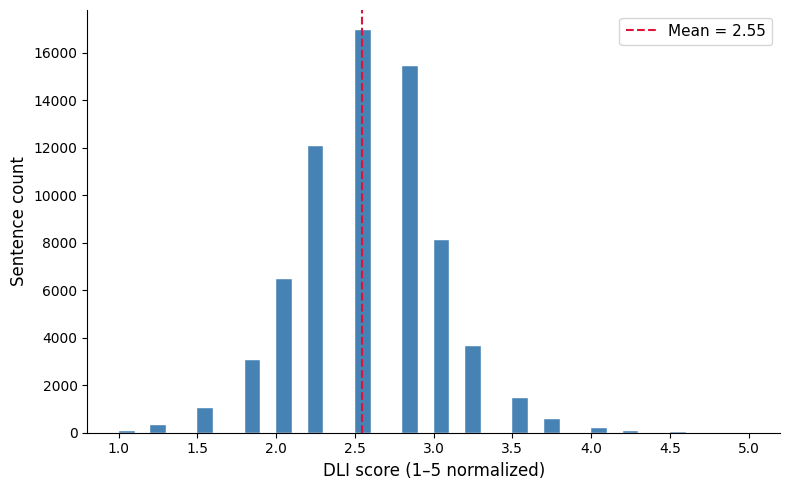

In [199]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(df_full['DLI_1_5_norm'].dropna(), bins=40, 
        color='steelblue', edgecolor='white', linewidth=0.3)

ax.axvline(df_full['DLI_1_5_norm'].mean(), color='crimson', 
           linewidth=1.5, linestyle='--', label=f"Mean = {df_full['DLI_1_5_norm'].mean():.2f}")

ax.set_xlabel('DLI score (1–5 normalized)', fontsize=12)
ax.set_ylabel('Sentence count', fontsize=12)
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../results/figures/dli_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

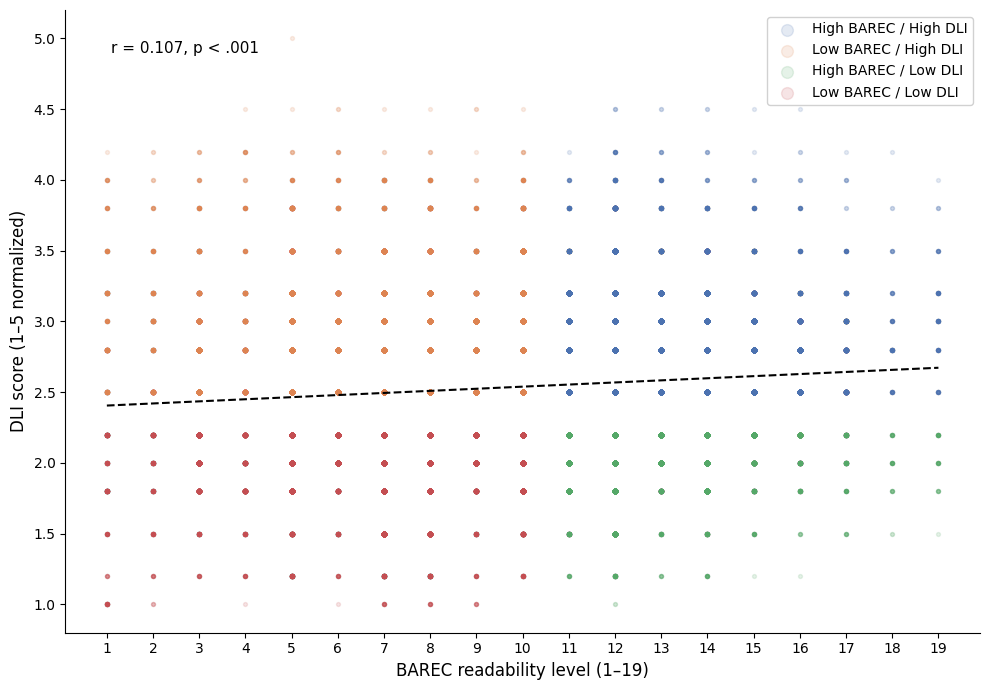

In [200]:
from matplotlib.patches import Patch

colors = {
    'High BAREC / High DLI': '#4C72B0',
    'Low BAREC / High DLI':  '#DD8452',
    'High BAREC / Low DLI':  '#55A868',
    'Low BAREC / Low DLI':   '#C44E52'
}

fig, ax = plt.subplots(figsize=(10, 7))

for quadrant, color in colors.items():
    subset = df_full[df_full['Quadrant'] == quadrant]
    ax.scatter(subset['Readability_Level_19'], subset['DLI_1_5_norm'],
               alpha=0.15, s=8, color=color, label=quadrant)

# Correlation line
from scipy import stats
slope, intercept, r, p, _ = stats.linregress(
    df_full['Readability_Level_19'], df_full['DLI_1_5_norm'])
x_range = range(1, 20)
ax.plot(x_range, [slope*x + intercept for x in x_range], 
        color='black', linewidth=1.5, linestyle='--')

ax.set_xlabel('BAREC readability level (1–19)', fontsize=12)
ax.set_ylabel('DLI score (1–5 normalized)', fontsize=12)
ax.set_xticks(range(1, 20))
ax.text(0.05, 0.95, f'r = {r:.3f}, p < .001', transform=ax.transAxes,
        fontsize=11, verticalalignment='top')
ax.legend(markerscale=3, fontsize=10, framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
# plt.savefig('dli_vs_barec.png', dpi=200, bbox_inches='tight')
plt.show()

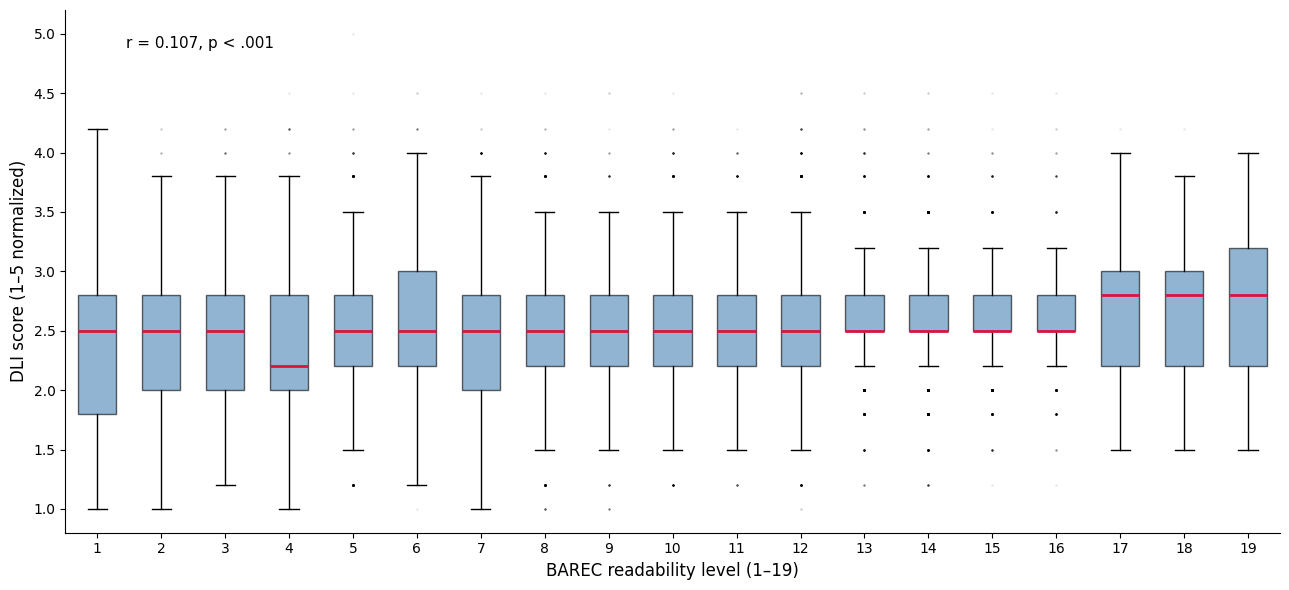

In [234]:
fig, ax = plt.subplots(figsize=(13, 6))

data_by_level = [df_full[df_full['Readability_Level_19'] == lvl]['DLI_1_5_norm'].values
                 for lvl in range(1, 20)]

bp = ax.boxplot(data_by_level, positions=range(1, 20),
                patch_artist=True, widths=0.6,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                medianprops=dict(color='crimson', linewidth=2),
                flierprops=dict(marker='.', markersize=1, alpha=0.15, color='gray'),
                whiskerprops=dict(linewidth=1),
                capprops=dict(linewidth=1))

ax.set_xlabel('BAREC readability level (1–19)', fontsize=12)
ax.set_ylabel('DLI score (1–5 normalized)', fontsize=12)
ax.set_xticks(range(1, 20))
ax.text(0.05, 0.95, 'r = 0.107, p < .001',
        transform=ax.transAxes, fontsize=11, verticalalignment='top')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('dli_vs_barec_boxplot.png', dpi=200, bbox_inches='tight')
plt.show()

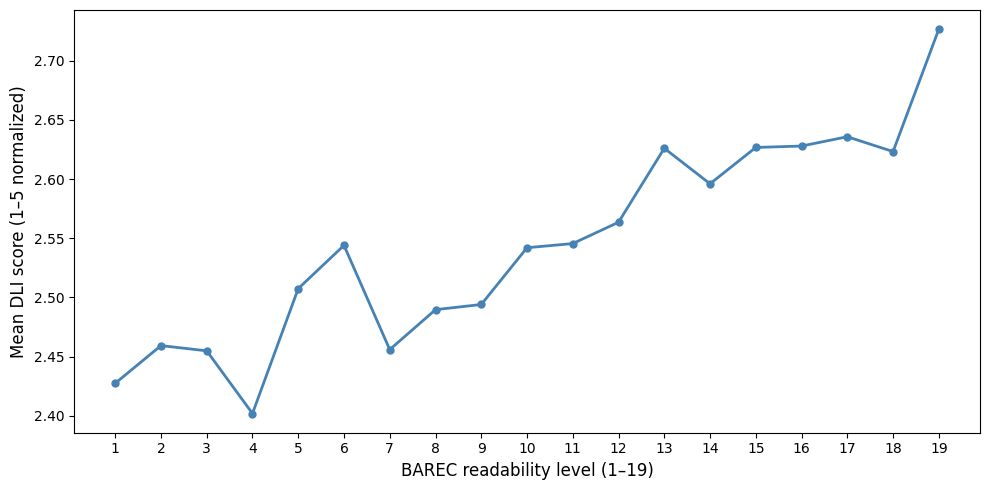

In [237]:
mean_dli = df_full.groupby('Readability_Level_19')['DLI_1_5_norm'].agg(['mean', 'sem'])

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(mean_dli.index, mean_dli['mean'], 
        color='steelblue', linewidth=2, marker='o', markersize=5)

ax.set_xlabel('BAREC readability level (1–19)', fontsize=12)
ax.set_ylabel('Mean DLI score (1–5 normalized)', fontsize=12)
ax.set_xticks(range(1, 20))


plt.tight_layout()
plt.savefig('mean_dli_per_barec.png', dpi=200, bbox_inches='tight')
plt.show()

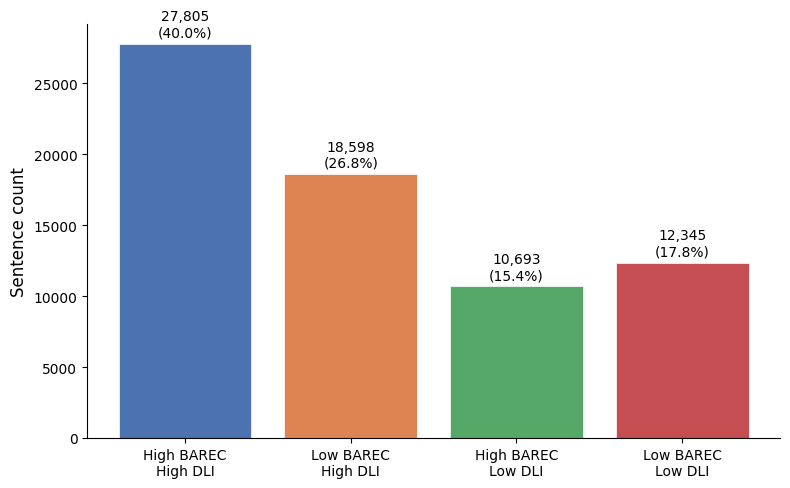

In [202]:
quadrant_counts = df_full['Quadrant'].value_counts()

order = ['High BAREC / High DLI', 'Low BAREC / High DLI',
         'High BAREC / Low DLI',  'Low BAREC / Low DLI']
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar([o.replace(' / ', '\n') for o in order],
              [quadrant_counts[o] for o in order],
              color=colors, edgecolor='white', linewidth=0.5)

for bar, o in zip(bars, order):
    count = quadrant_counts[o]
    pct = count / len(df_full) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Sentence count', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
# plt.savefig('quadrant_distribution.png', dpi=200, bbox_inches='tight')
plt.show()

In [238]:
examples = [
    'يُعْجِبُني',
    'بِسْبِسَةُ الشَّعْرِ',
    'لا يلقى فى الدرب الا العلل',
    'هيا يا أبا الظرفاء'
]

for s in examples:
    row = df_full[df_full['Sentence'] == s]
    if len(row) > 0:
        print(f"Sentence: {s}")
        print(f"BAREC: {row['Readability_Level_19'].values[0]}")
        print(f"DLI_norm: {row['DLI_1_5_norm'].values[0]:.2f}")
        print(f"OVL: {row['OVL'].values[0]:.2f}")
        print(f"DLP: {row['DLP'].values[0]:.2f}")
        print(f"LD: {row['Lexical_Difficulty'].values[0]:.2f}")
        print("---")
    else:
        print(f"NOT FOUND: {s}")

Sentence: يُعْجِبُني
BAREC: 5
DLI_norm: 5.00
OVL: 0.67
DLP: 0.83
LD: 3.00
---
NOT FOUND: بِسْبِسَةُ الشَّعْرِ
Sentence: لا يلقى فى الدرب الا العلل
BAREC: 12
DLI_norm: 1.00
OVL: 0.00
DLP: 0.19
LD: 1.50
---
NOT FOUND: هيا يا أبا الظرفاء


In [241]:
# DLI by domain
domain_stats = df_full.groupby('Domain')['DLI_1_5_norm'].agg(['mean', 'std', 'median', 'count'])
print(domain_stats)

# also correlation with BAREC per domain
from scipy import stats
for domain in df_full['Domain'].unique():
    subset = df_full[df_full['Domain'] == domain]
    r, p = stats.pearsonr(subset['Readability_Level_19'], subset['DLI_1_5_norm'])
    print(f"{domain}: r = {r:.3f}, p = {p:.4f}, n = {len(subset)}")

                       mean       std  median  count
Domain                                              
Arts & Humanities  2.539353  0.473053     2.5  50558
STEM               2.565688  0.359020     2.5   4666
Social Sciences    2.567637  0.387904     2.5  14217
Arts & Humanities: r = 0.119, p = 0.0000, n = 50558
STEM: r = 0.135, p = 0.0000, n = 4666
Social Sciences: r = 0.023, p = 0.0052, n = 14217
